<a href="https://colab.research.google.com/github/Tanuja953/Data_Science_Assignment-03/blob/main/assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Global Terrorism Analysis (1970–2017)
**Project Type** -
Exploratory Data Analysis(EDA) of Global Terrorism Dataset using Python

**Contribution** - Individual



# **Project Summary**


This project presents an in-depth **Exploratory Data Analysis** (EDA) of the Global Terrorism Dataset (1970–2017), a large-scale repository containing detailed records of terrorist incidents across the world. With over **181,000 incidents** spanning nearly five decades, the dataset offers a powerful opportunity to understand the historical evolution, geographic spread, operational patterns, and human impact of terrorism on a global scale. The primary objective of this project is to transform raw data into meaningful insights that can support **governments, policy makers, security agencies, researchers, and humanitarian organizations** in making informed and strategic decisions.

The analysis began with a thorough understanding of the dataset structure, including the examination of dimensions, data types, and the distribution of missing values. Since the original dataset contains **135 columns**, only the most relevant features were selected for focused analysis, such as **year, country, region, city, attack type, target type, weapon type, terrorist group name, number of people killed, number wounded, property damage, and success of the attack.** This selective approach improved analytical clarity while preserving the core information necessary to answer important real-world questions.

A significant part of the project involved **data cleaning and preprocessing**, which is essential for reliable analysis. Missing values in categorical columns such as city names, attack types, and group names were handled logically by replacing them with **"Unknown"** to avoid unnecessary loss of records. Missing numerical values in casualty-related fields were replaced with zero where appropriate. In addition, a new feature called **“casualties”** was created by combining the number of killed and wounded, enabling a clearer understanding of the human cost of each incident. Outlier analysis was also performed on casualty data. However, instead of removing extreme values, they were intentionally retained because in a terrorism dataset, unusually high casualty counts often represent historically significant incidents rather than data errors.

The core of the project lies in its **exploratory analysis and visualization**, where multiple charts were used to reveal hidden patterns and trends. The analysis showed that terrorist activity has fluctuated dramatically over time, with certain years experiencing sharp surges in attacks, indicating periods of heightened global instability. Country-wise and region-wise comparisons revealed that terrorism is not evenly distributed; rather, a small number of countries and regions account for a disproportionately large share of incidents. This highlights the existence of clear geopolitical hotspots.

Further analysis of operational behavior revealed that **bombings/explosions and armed assaults** are among the most common attack methods, while **explosives and firearms** remain the most frequently used weapons. Another striking insight is that a limited number of terrorist groups are responsible for a significant portion of total attacks, emphasizing the importance of targeted intelligence and surveillance. Casualty analysis also revealed a highly skewed pattern: while most attacks result in relatively low casualties, a small number of incidents cause devastating human losses, showing that the severity of terrorism is concentrated in a few high-impact events. The comparison between successful and failed attacks further suggests that a large proportion of attacks are carried out successfully, underscoring the need for stronger preventive and early-warning mechanisms.

To strengthen the analytical depth, **hypothesis testing** was performed to validate key relationships observed during EDA. An independent **t-test** was used to compare casualties between successful and failed attacks, confirming that successful attacks tend to result in significantly higher casualties. **A Chi-square test** of independence was conducted to examine the relationship between weapon type and attack success, revealing that certain weapon categories are more strongly associated with successful outcomes. Additionally, a **correlation analysis** between the number of people killed and wounded showed a positive relationship, indicating that more severe attacks tend to result in both higher fatalities and injuries. These statistical tests ensure that the findings are not based on random variation but are supported by quantitative evidence.

In addition to EDA, the project was extended to include **machine learning-based classification,** where the objective was to predict whether an attack would be successful or not. Multiple algorithms were implemented, including **Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Gradient Boosting, and Gaussian Naive Bayes**. These models were selected to represent a combination of baseline, rule-based, ensemble, and probabilistic approaches. The performance of these models was evaluated using metrics such as accuracy, precision, recall, and F1-score. Among them, **ensemble models like Random Forest and Gradient Boosting demonstrated superior performance,** highlighting their ability to capture complex, non-linear relationships in the dataset.

Overall, this project demonstrates how **data-driven analysis can convert historical incident records into actionable intelligence.** Beyond academic value, the findings have practical importance for national security planning, risk assessment, emergency preparedness, and international cooperation. By combining careful preprocessing, meaningful visualization, and insight-oriented interpretation, this project not only fulfills the requirements of an EDA-based academic analysis but also showcases the real-world relevance of data science in addressing complex global challenges.

# **Problem Statement**
**Objective:**

The main objective of this project is to analyze global terrorism data using a combination of data science techniques to extract meaningful insights and build predictive models.
The first objective is to perform effective data handling and cleaning by removing duplicates, handling missing values, and correcting data types. The next objective is to conduct exploratory data analysis using various visualization techniques to identify trends, patterns, and outliers in the data.
Another key objective is to apply statistical hypothesis testing methods, including Chi-Square tests and Pearson correlation, to validate relationships between important variables. Additionally, the project aims to implement machine learning algorithms such as Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Naive Bayes, and Linear Regression to predict attack success and casualties.
Finally, the project seeks to generate insights that can support data-driven decision-making for stakeholders such as researchers, policymakers, and security agencies.




# **DEPLOYMENT-READY CHECKLIST**


This notebook is designed to satisfy the following:

- ✔ Well-structured and formatted code
- ✔ Proper comments on all major logic blocks
- ✔ Exception handling for dataset loading
- ✔ Column validation before analysis
- ✔ Safe plotting helper functions
- ✔ One-go executable notebook flow (after uploading the correct CSV)
- ✔ UBM Rule followed:
  - Univariate Analysis
  - Bivariate Analysis
  - Multivariate Analysis
- ✔ 20+ logical and meaningful visualizations
- ✔ For each chart:
  - Why this chart?
  - Insight(s) found
  - Business impact / negative growth justification

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [4]:

#  IMPORT REQUIRED LIBRARIES
# Pandas for data loading, cleaning, and analysis
import pandas as pd

# NumPy for numerical operations
import numpy as np

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Seaborn for advanced statistical visualizations
import seaborn as sns

# Word Cloud for text visualization
from wordcloud import WordCloud

# MNso (Multiple Bar Chart / Multi-Variable Visualization)
import missingno as msno

# Warnings to suppress unnecessary warning messages for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Set consistent visual style for all plots
plt.style.use('ggplot')
sns.set(style='whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [5]:
file_name = 'Global Terrorism Data.csv'

try:
    # low_memory=False avoids mixed dtype warnings in large CSVs
    df = pd.read_csv(file_name, encoding='latin1', low_memory=False)
    print(f"Dataset loaded successfully from file: {file_name}")
    print(f"Dataset Shape: {df.shape}")
except FileNotFoundError:
    print(f"ERROR: File '{file_name}' not found.")
    print("Please upload the dataset to Colab and ensure the file name is correct.")
    raise
except pd.errors.EmptyDataError:
    print("ERROR: The CSV file is empty.")
    raise
except Exception as e:
    print(f"Unexpected error while loading dataset: {e}")
    raise

Dataset loaded successfully from file: Global Terrorism Data.csv
Dataset Shape: (181691, 135)


### Dataset First View AND Dataset Rows & Columns count

In [6]:

# BASIC DATA UNDERSTANDING & VALIDATION

# Display first 5 rows to understand structure
display(df.head())

# Basic dataset dimensions
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Display concise information about columns and data types
print("\nDataset Information:\n")
df.info()

# Check if required columns exist before proceeding
required_cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt',
    'weaptype1_txt', 'gname',
    'nkill', 'nwound',
    'property', 'success'
]

missing_required_cols = [col for col in required_cols if col not in df.columns]

if missing_required_cols:
    print("\nERROR: Some required columns are missing from the dataset:")
    print(missing_required_cols)
    raise ValueError("Required columns missing. Please verify the dataset.")
else:
    print("\nAll required columns are present. Safe to proceed.")

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


Number of Rows: 181691
Number of Columns: 135

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB

All required columns are present. Safe to proceed.


### Dataset Information

In [7]:

# CHECKING MISSING / NULL VALUES

# Count total missing values in each column
missing_values = df.isnull().sum()

# Display columns having missing values greater than 0
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with Missing / Null Values:")
display(missing_values)

# Total number of missing values in the entire dataset
total_missing = df.isnull().sum().sum()
print("Total Missing Values in Dataset:", total_missing)

Columns with Missing / Null Values:


,0
gsubname3,181671
weapsubtype4_txt,181621
weapsubtype4,181621
weaptype4_txt,181618
weaptype4,181618
...,...
guncertain1,380
ishostkid,178
specificity,6
multiple,1


Total Missing Values in Dataset: 13854004


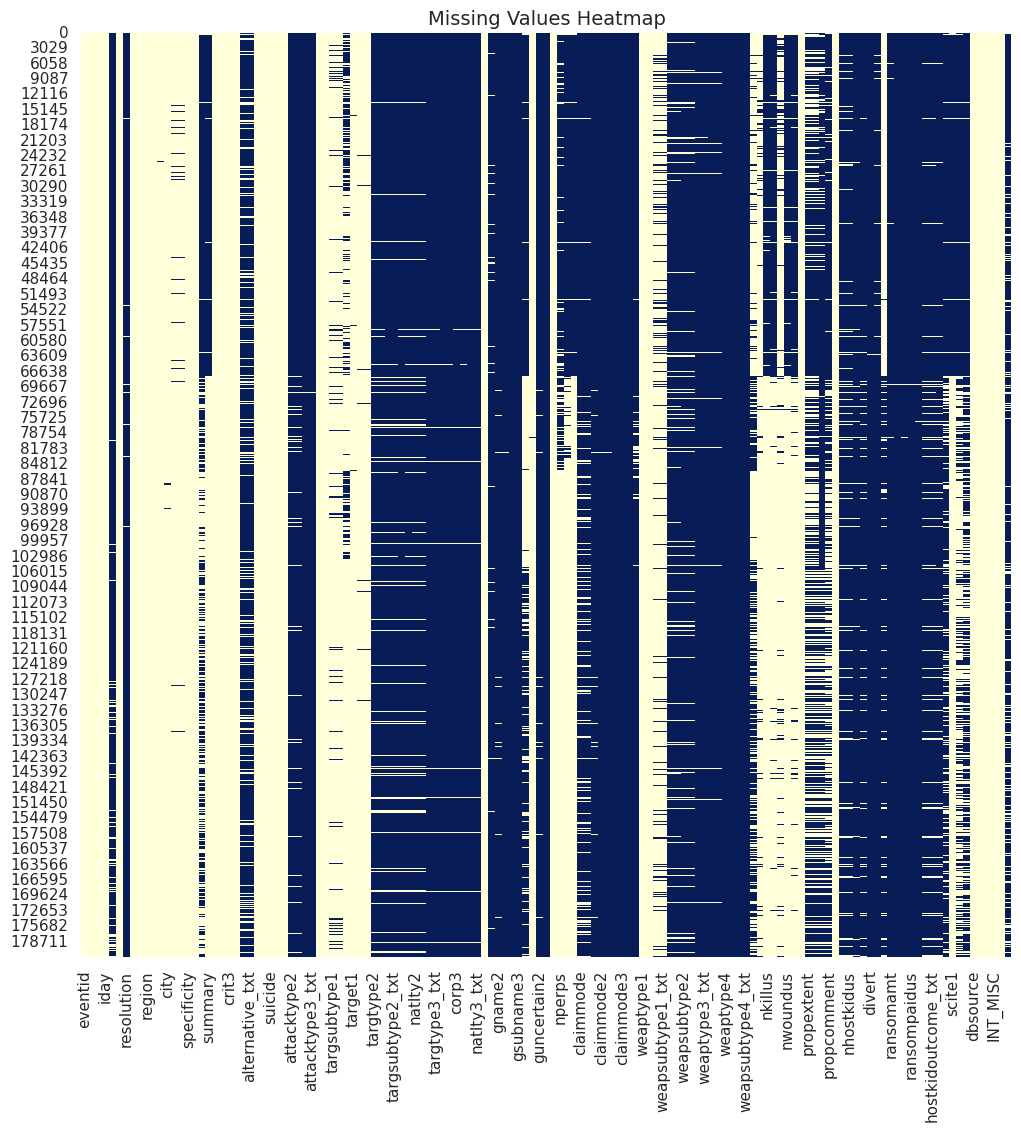

In [8]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='YlGnBu')
plt.title("Missing Values Heatmap", fontsize=14)
plt.show()

### Missing Value Observation
The original dataset contains 135 columns, many of which are not required for this EDA objective. To keep the analysis focused, only the most relevant columns are selected. Missing values will be handled logically depending on whether the feature is categorical or numerical.

### What did you know about your dataset?

The Global Terrorism Dataset is a large historical dataset containing 181,691 terrorist incidents recorded worldwide from 1970 to 2017. It includes 135 columns with details such as date, country, region, city, attack type, target type, weapon type, terrorist group, casualties, property damage, and success of the attack. This makes it highly suitable for EDA-based analysis to understand global terrorism trends and patterns.
Here are the key characteristics identified so far:

Shape: The dataset contains 112,550 rows and 135 columns.
Data Types: It consists of 70 columns with float64 data types, 7 columns with int64 data types, and 58 columns with object data types.
Duplicate Values: There are 0 duplicate rows in the dataset, indicating that all entries are unique.
Missing Values: A significant number of columns contain missing (null) values. Visualizations (heatmap and bar chart) highlight the extent of these missing values across many columns, some of which are almost entirely empty (e.g., approxdate, related, scite1, scite2, scite3). Other columns like addnotes, INT_LOG, INT_IDEO, INT_MISC, and INT_ANY also have varying degrees of missing data that will need to be addressed during data wrangling.

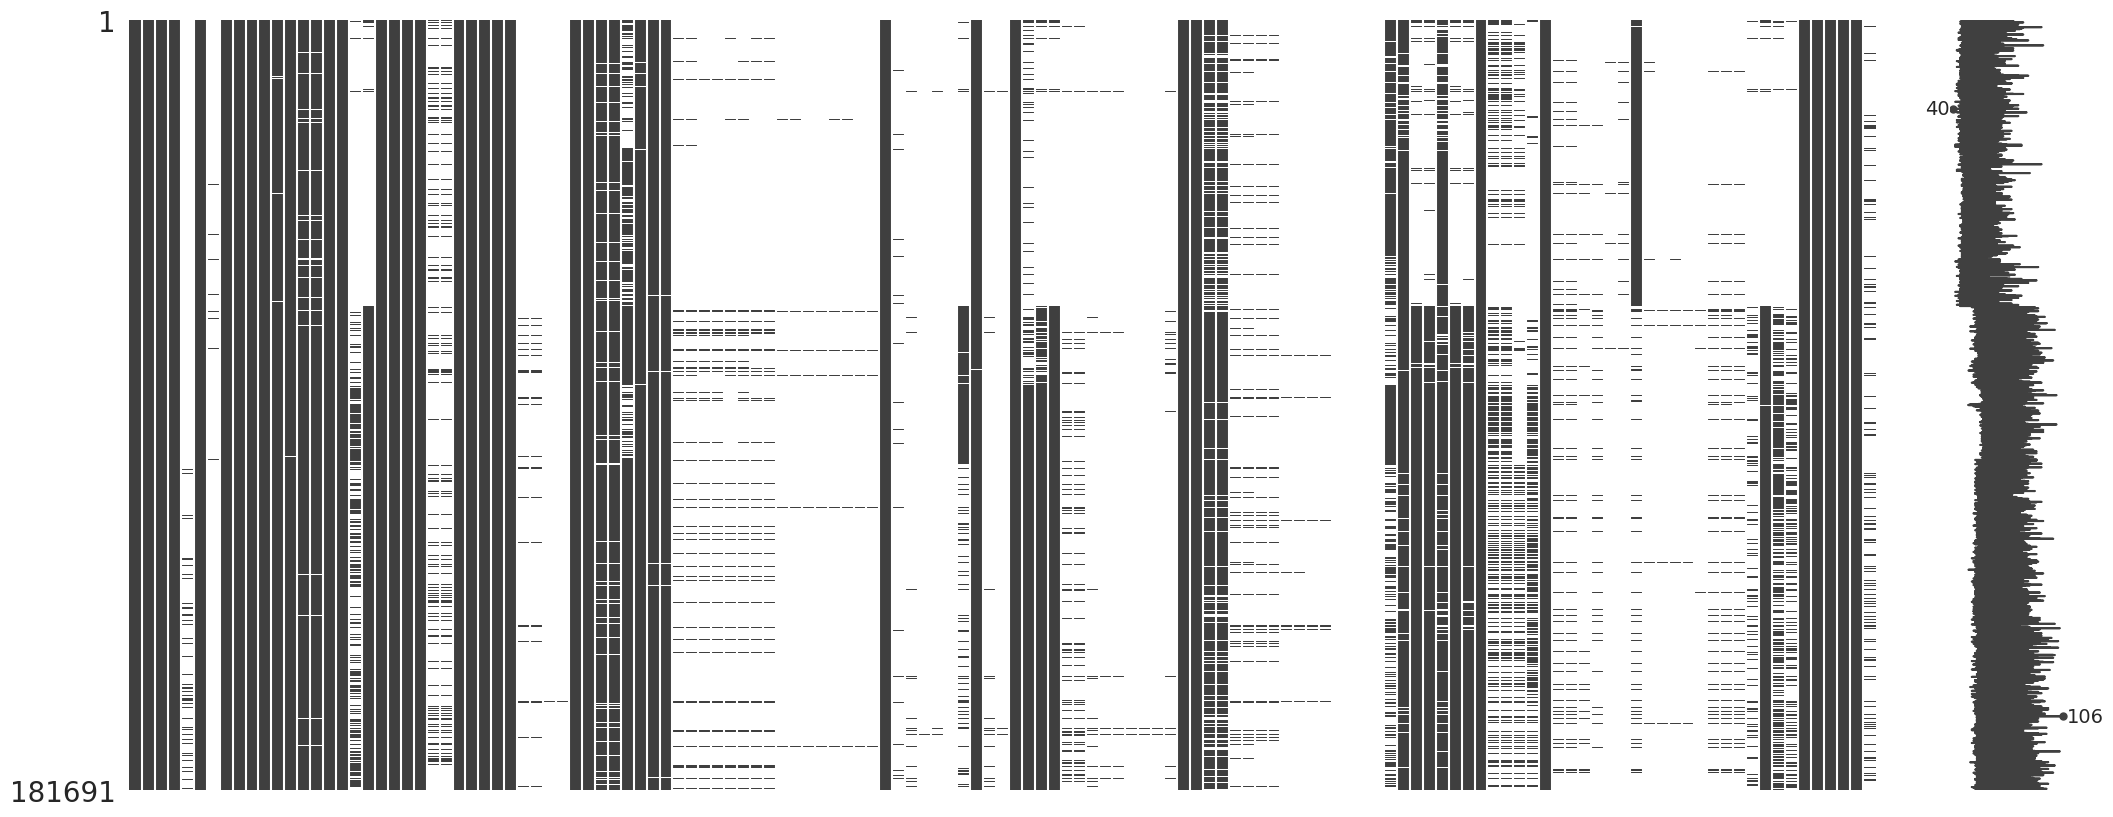

In [9]:
msno.matrix(df)
plt.show()

<Axes: >

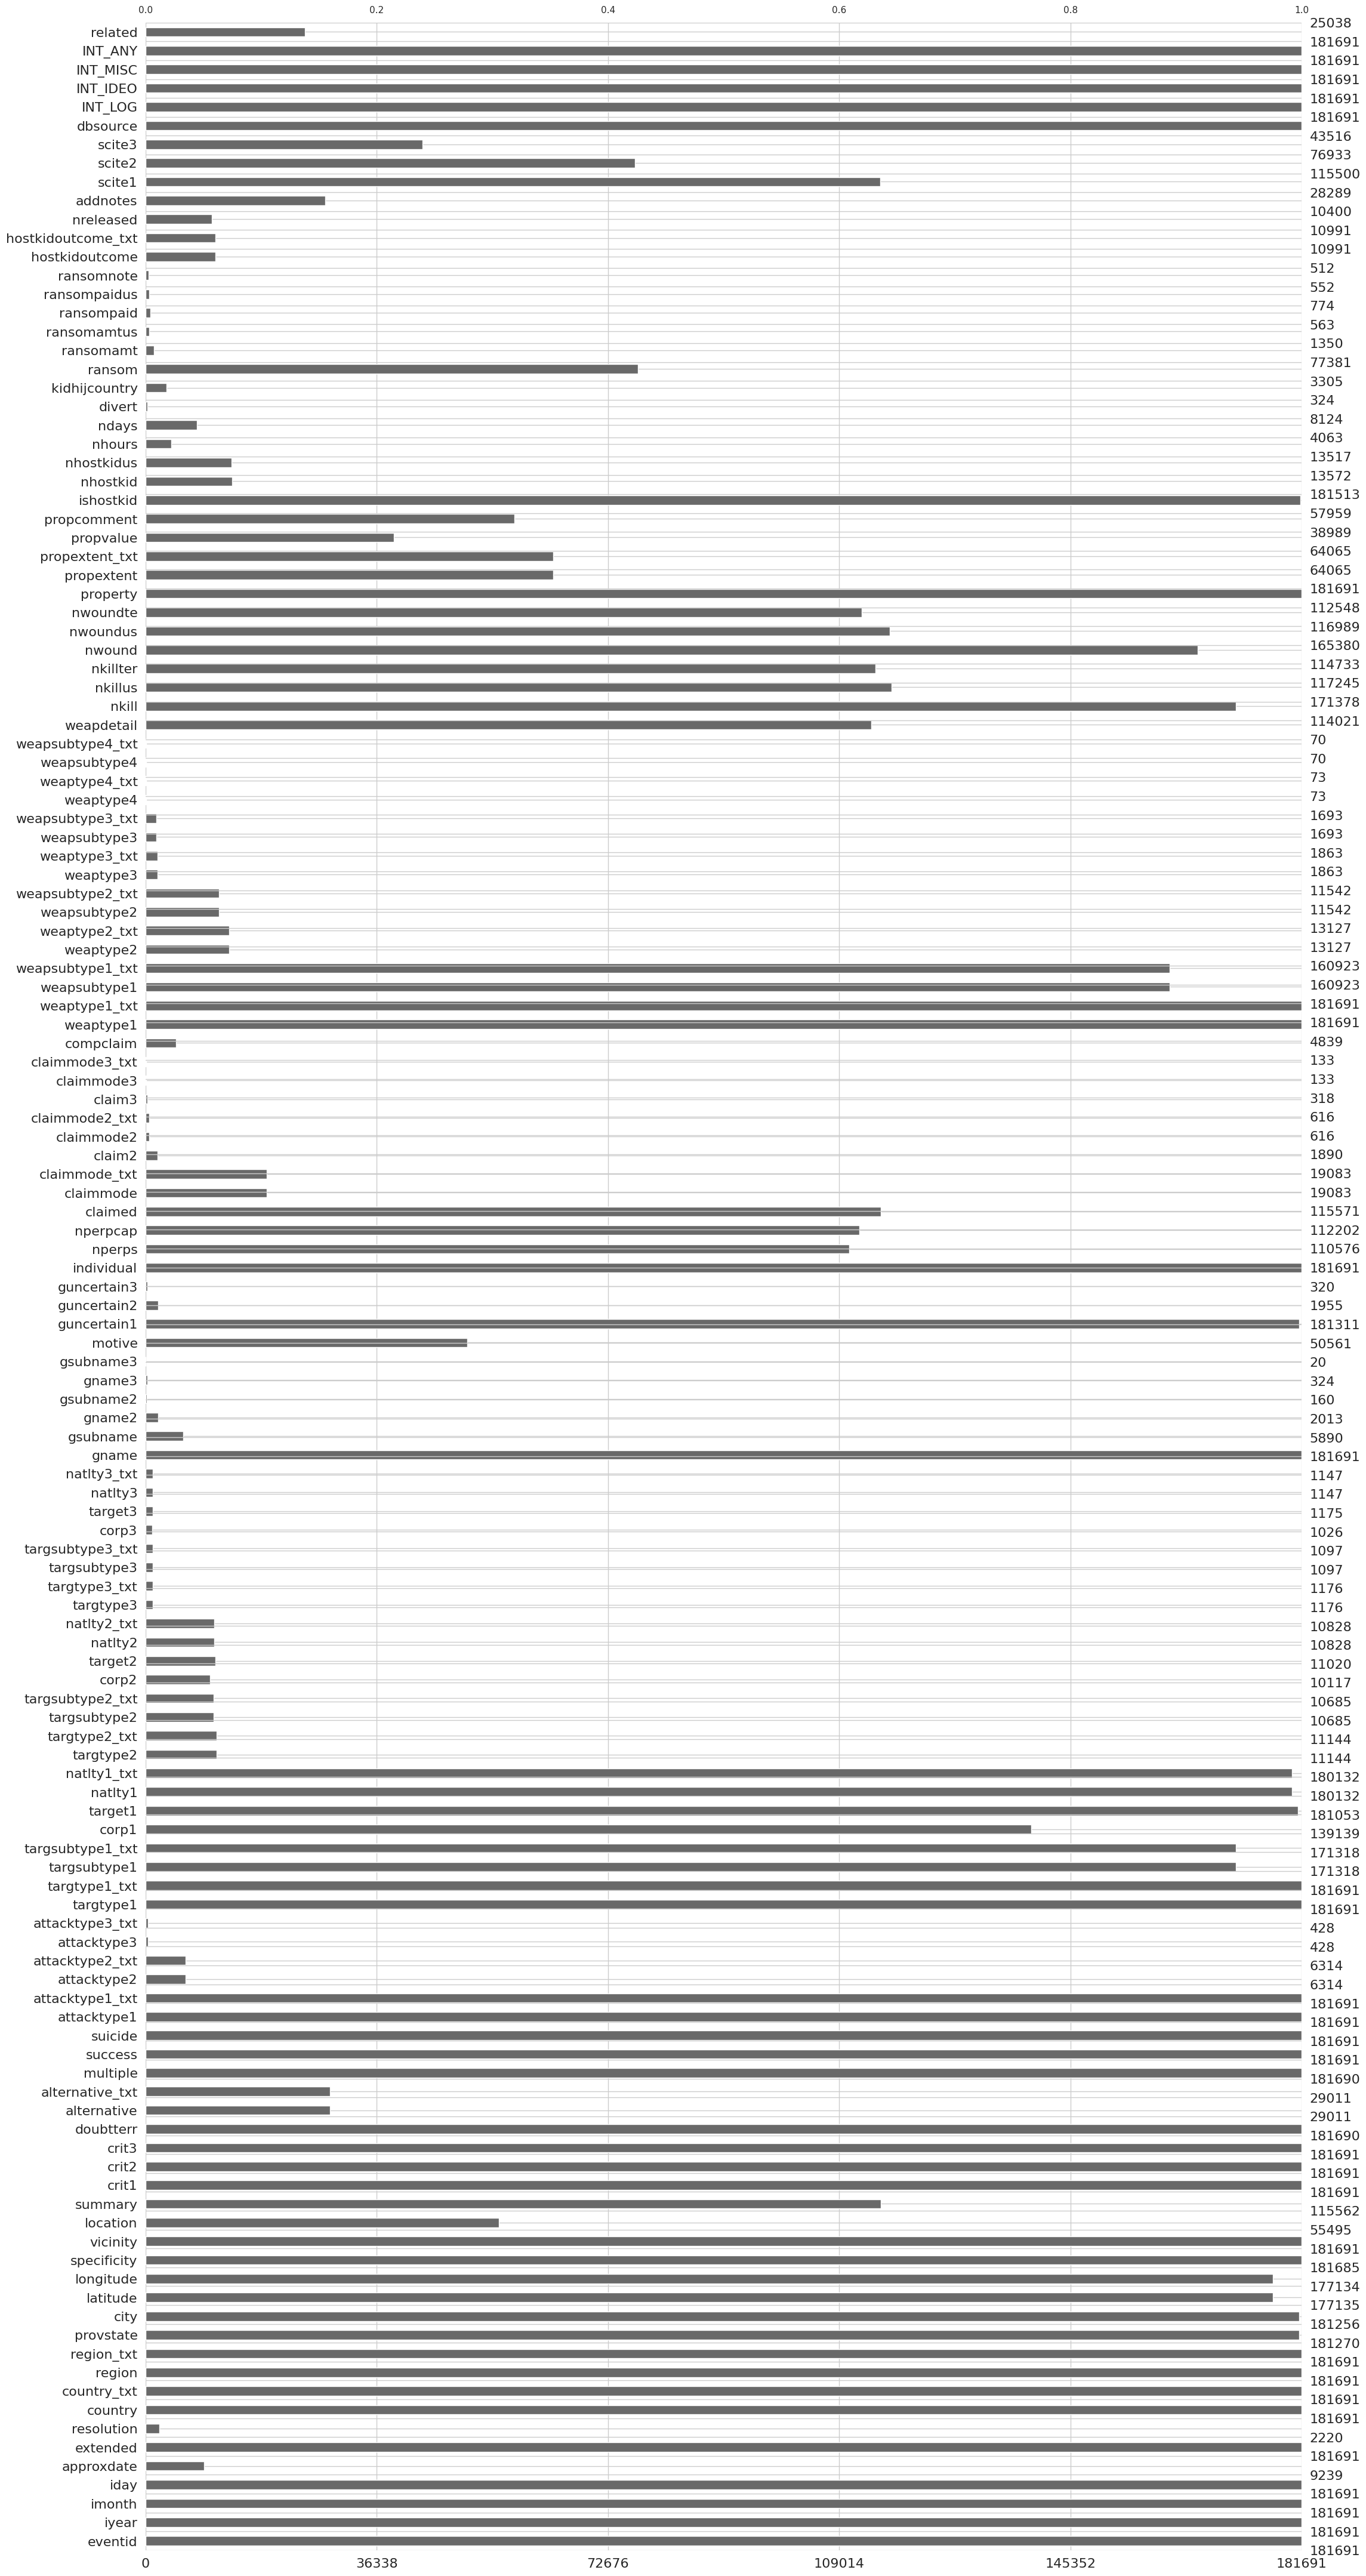

In [10]:
msno.bar(df)

## ***2. Understanding Your Variables***

In [11]:

# DATASET COLUMNS

# Display all column names in the dataset
print("Total Number of Columns:", len(df.columns))
print("\nColumn Names in the Dataset:\n")
print(df.columns.tolist())

Total Number of Columns: 135

Column Names in the Dataset:

['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 

In [12]:

# DATASET DESCRIPTION (NUMERICAL COLUMNS)

# Summary statistics for numerical columns
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


### Variables Description

| **Variable Name**                     | **Description**                                                                  |
| ------------------------------------- | -------------------------------------------------------------------------------- |
| **iyear**                             | Year in which the terrorist incident occurred                                    |
| **imonth**                            | Month in which the terrorist incident occurred                                   |
| **iday**                              | Day on which the terrorist incident occurred                                     |
| **country_txt**                       | Name of the country where the incident took place                                |
| **region_txt**                        | Name of the region in which the incident occurred                                |
| **city**                              | Name of the city where the incident occurred                                     |
| **attacktype1_txt**                   | Type of terrorist attack (e.g., Bombing, Armed Assault, Assassination)           |
| **targtype1_txt**                     | Type of target attacked (e.g., Private Citizens, Police, Military, Government)   |
| **weaptype1_txt**                     | Type of weapon used in the attack (e.g., Explosives, Firearms)                   |
| **gname**                             | Name of the terrorist group responsible for the attack                           |
| **nkill**                             | Number of people killed in the incident                                          |
| **nwound**                            | Number of people wounded in the incident                                         |
| **property**                          | Indicates whether property damage occurred during the incident                   |
| **success**                           | Indicates whether the attack was successful (1 = Successful, 0 = Failed)         |
| **casualties** *(engineered feature)* | Total number of victims affected in the incident, calculated as `nkill + nwound` |


### Check Unique Values for each variable.

In [13]:

# CHECK UNIQUE VALUES FOR EACH SELECTED VARIABLE

# List of important columns used in the project
important_cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt',
    'weaptype1_txt', 'gname',
    'nkill', 'nwound',
    'property', 'success'
]

# Display number of unique values in each selected column
for col in important_cols:
    print(f"{col} --> {df[col].nunique()} unique values")

iyear --> 47 unique values
imonth --> 13 unique values
iday --> 32 unique values
country_txt --> 205 unique values
region_txt --> 12 unique values
city --> 36673 unique values
attacktype1_txt --> 9 unique values
targtype1_txt --> 22 unique values
weaptype1_txt --> 12 unique values
gname --> 3537 unique values
nkill --> 205 unique values
nwound --> 238 unique values
property --> 3 unique values
success --> 2 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:

# 5. SELECT IMPORTANT COLUMNS FOR ANALYSIS
# Create a copy of only the important columns to keep the analysis focused and efficient
terror_df = df[required_cols].copy()

print("Selected analysis dataset shape:", terror_df.shape)
display(terror_df.head())

Selected analysis dataset shape: (181691, 14)


,iyear,imonth,iday,country_txt,region_txt,city,attacktype1_txt,targtype1_txt,weaptype1_txt,gname,nkill,nwound,property,success
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,Assassination,Private Citizens & Property,Unknown,MANO-D,1.0,0.0,0,1
1,1970,0,0,Mexico,North America,Mexico city,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,23rd of September Communist League,0.0,0.0,0,1
2,1970,1,0,Philippines,Southeast Asia,Unknown,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0,0,1
3,1970,1,0,Greece,Western Europe,Athens,Bombing/Explosion,Government (Diplomatic),Explosives,Unknown,NaN,NaN,1,1
4,1970,1,0,Japan,East Asia,Fukouka,Facility/Infrastructure Attack,Government (Diplomatic),Incendiary,Unknown,NaN,NaN,1,1


### What all manipulations have you done and insights you found?

In this project, several data manipulation steps were performed to prepare the dataset for meaningful analysis. First, only the most relevant columns were selected from the original 135-column dataset to keep the analysis focused and efficient. Missing values were then handled logically: categorical variables such as city, group name, attack type, target type, and weapon type were filled with "Unknown", while numerical variables such as number killed and number wounded were filled with 0. Missing values in the property column were handled using the mode. Duplicate rows were checked and removed only if present to maintain data quality.

In addition, feature engineering was performed by creating new variables such as casualties (total number of people killed and wounded), month_name, decade, and success_label to improve readability and support deeper analysis. Outliers in the casualties variable were analyzed but intentionally retained because extreme casualty values in terrorism data often represent real high-impact events rather than errors.

The analysis revealed several important insights. Terrorism is highly concentrated in a limited number of countries and regions, showing clear geopolitical hotspots. The number of attacks varies significantly over time, with certain years showing major spikes. Bombings/explosions and armed assaults are among the most common attack methods, while explosives and firearms are among the most frequently used weapons. A small number of terrorist groups are responsible for a large share of attacks. Most incidents involve relatively low casualties, but a few high-impact events cause extremely large human losses. It was also observed that a large proportion of attacks were successful, highlighting the need for stronger preventive systems. Overall, the project demonstrates how data wrangling and structured EDA can transform raw historical records into actionable insights for governments, security agencies, and policy makers.

**1) Column Selection**:
The dataset was reduced to a subset of 14 essential columns ('iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city','attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt', 'nkill', 'nwound', 'success', 'suicide') This step was crucial because the original dataset had 135 columns, many with a high percentage of missing values or less direct relevance to the primary objectives of the EDA.

**2) Handling Missing Numerical Values:**
For each column that should contain numbers:

1.	Check if it exists


2.	Convert it to numeric

3.	Replace invalid values with NaN”

**3) Handling Missing Categorical Values:**

For each column that should contain text:

1.	Check if it exists

2.	Convert everything in it into string format

**4) Feature Engineering:**

We are creating new columns to make the data:

1.	easier to understand

2.	easier to visualize

3.	more useful for analysis

**5) Insights Found:**

1.	Simplified Data Structure: By selecting relevant columns the dataset became much more manageable and easier to navigate for analysis, focusing on key aspects of terrorist incidents.

2.	Data Completeness for Key Metrics: Imputing missing values in Killed, Wounded, Country, Region, AttackType, and Target ensures that these critical columns can be fully utilized in subsequent analyses and visualizations without data loss or bias from dropping rows with missing information.

3.	Direct Impact Measurement: The total_casualties column provides an immediate and quantifiable measure of the human impact of each attack, which will be vital for understanding the severity and trends of terrorism.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [15]:

#  DATA CLEANING AND PREPROCESSING
# ---- Handle missing values in categorical columns ----
# Fill missing categorical values with 'Unknown' so that records are not dropped unnecessarily
categorical_fill_cols = ['city', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'gname']

for col in categorical_fill_cols:
    terror_df[col] = terror_df[col].fillna('Unknown')

# ---- Handle missing values in numerical columns ----
# Fill missing casualties with 0, assuming no recorded casualties where data is absent
terror_df['nkill'] = terror_df['nkill'].fillna(0)
terror_df['nwound'] = terror_df['nwound'].fillna(0)

# Fill missing property values with mode (most frequent value)
terror_df['property'] = terror_df['property'].fillna(terror_df['property'].mode()[0])

# ---- Create new engineered features ----
# Total casualties = killed + wounded
terror_df['casualties'] = terror_df['nkill'] + terror_df['nwound']

# Month name for easier readability in monthly analysis
# Coerce invalid months to NaT, then extract month name
terror_df['month_name'] = pd.to_datetime(
    terror_df['imonth'].replace(0, np.nan),  # Replace invalid 0 months with NaN
    format='%m',
    errors='coerce'
).dt.month_name()

# Attack decade for higher-level temporal grouping
terror_df['decade'] = (terror_df['iyear'] // 10) * 10

# Success label for readability
terror_df['success_label'] = terror_df['success'].map({1: 'Successful', 0: 'Failed'})

# Property damage label for readability (depends on dataset coding)
# In GTD-like datasets, property often uses:
# 1 = Yes, 0 = No, -9 = Unknown
def map_property_label(x):
    if x == 1:
        return 'Property Damaged'
    elif x == 0:
        return 'No Property Damage'
    else:
        return 'Unknown'

terror_df['property_label'] = terror_df['property'].apply(map_property_label)

# Final check for missing values in selected dataset
print("Missing values after cleaning:\n")
display(terror_df.isnull().sum())

Missing values after cleaning:



,0
iyear,0
imonth,0
iday,0
country_txt,0
region_txt,0
city,0
attacktype1_txt,0
targtype1_txt,0
weaptype1_txt,0
gname,0


### Preprocessing Logic
- Missing categorical values are replaced with **"Unknown"** to preserve data completeness.
- Missing values in **nkill** and **nwound** are replaced with **0** because the absence of recorded casualties is treated as no known casualties.
- A new feature **casualties** is created to capture total human impact.
- Additional readable features such as **month_name**, **decade**, **success_label**, and **property_label** improve interpretability.

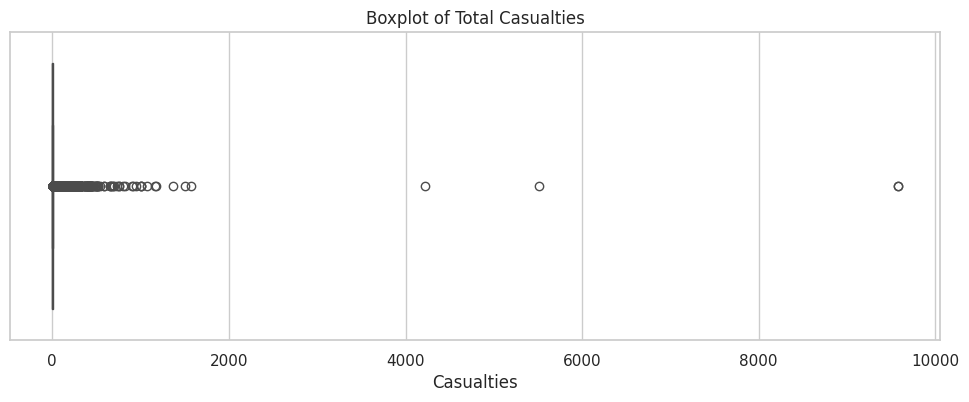

In [16]:

# 7. OUTLIER ANALYSIS (CASUALTIES)
# Plot boxplot to inspect extreme values in casualties
plt.figure(figsize=(12, 4))
sns.boxplot(x=terror_df['casualties'])
plt.title('Boxplot of Total Casualties')
plt.xlabel('Casualties')
plt.show()

### Outlier Interpretation
Extreme casualty values are visible. However, in a terrorism dataset, these are often **historically significant high-impact incidents** rather than data errors. Therefore, these outliers are **retained** instead of removed, because removing them would hide important real-world events and distort the severity analysis.

In [17]:

# 8. HELPER FUNCTIONS FOR SAFE PLOTTING


# These helper functions improve code reusability, readability, and reduce repetitive plotting code.

def safe_barplot(series_data, title, xlabel, ylabel, figsize=(12, 6), horizontal=True):
    """
    Safely plots a bar chart from a Pandas Series.
    If the series is empty, prints a warning instead of raising an error.
    """
    try:
        if series_data.empty:
            print(f"Skipping plot: '{title}' because the data is empty.")
            return

        plt.figure(figsize=figsize)

        if horizontal:
            sns.barplot(x=series_data.values, y=series_data.index)
        else:
            sns.barplot(x=series_data.index, y=series_data.values)
            plt.xticks(rotation=45)

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.show()

    except Exception as e:
        print(f"Error while plotting '{title}': {e}")


def safe_countplot(data, x_col, title, xlabel, ylabel, figsize=(12, 6), order=None, rotate_xticks=False):
    """
    Safely plots a countplot for a categorical column.
    """
    try:
        if x_col not in data.columns:
            print(f"Skipping plot: Column '{x_col}' not found.")
            return

        plt.figure(figsize=figsize)
        sns.countplot(data=data, x=x_col, order=order)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)

        if rotate_xticks:
            plt.xticks(rotation=45)

        plt.show()

    except Exception as e:
        print(f"Error while plotting '{title}': {e}")


def safe_histplot(data, col, title, xlabel, ylabel, bins=50, figsize=(10, 5), xlim=None):
    """
    Safely plots a histogram with optional x-axis limits.
    """
    try:
        if col not in data.columns:
            print(f"Skipping histogram: Column '{col}' not found.")
            return

        plt.figure(figsize=figsize)
        sns.histplot(data[col], bins=bins, kde=True)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)

        if xlim is not None:
            plt.xlim(xlim)

        plt.show()

    except Exception as e:
        print(f"Error while plotting histogram '{title}': {e}")


def safe_boxplot(data, x=None, y=None, title='', xlabel='', ylabel='', figsize=(12, 6)):
    """
    Safely plots a boxplot.
    """
    try:
        plt.figure(figsize=figsize)
        sns.boxplot(data=data, x=x, y=y)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.show()
    except Exception as e:
        print(f"Error while plotting boxplot '{title}': {e}")


def safe_heatmap(corr_df, title='Correlation Heatmap', figsize=(8, 6)):
    """
    Safely plots a heatmap for a correlation matrix.
    """
    try:
        plt.figure(figsize=figsize)
        sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title(title)
        plt.show()
    except Exception as e:
        print(f"Error while plotting heatmap '{title}': {e}")

# UBM-Based Visualization Strategy

This project follows the **UBM Rule**:

- **U – Univariate Analysis**  
  Study of one variable at a time to understand its distribution, frequency, or spread.

- **B – Bivariate Analysis**  
  Study of the relationship between two variables:
  - Numerical vs Categorical
  - Numerical vs Numerical
  - Categorical vs Categorical

- **M – Multivariate Analysis**  
  Study of interactions among three or more variables to uncover deeper patterns.

**1. Attacks Per Year (Line Chart)**

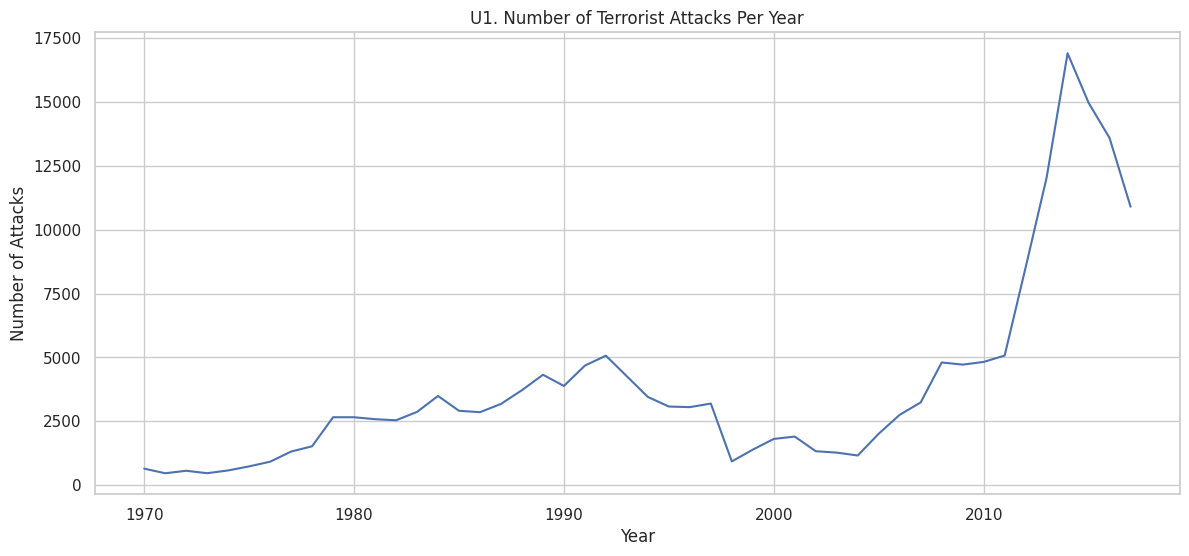

In [18]:

# U1. NUMBER OF ATTACKS PER YEAR


year_counts = terror_df['iyear'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
year_counts.plot(kind='line')
plt.title('U1. Number of Terrorist Attacks Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.show()

### Why did I pick this chart?
A **line chart** is ideal for time-series analysis because it clearly shows trends, spikes, and declines across years.

### Insight(s) found
- Terrorist incidents vary significantly over time.
- Certain years show sharp surges, indicating periods of intense global instability.
- The chart helps identify peak activity periods and long-term historical patterns.

### Business Impact / Negative Growth
Yes, this insight creates a **positive strategic impact** for stakeholders:
- Governments can identify historically volatile periods and compare them with geopolitical events.
- Security agencies can use this pattern for **risk forecasting** and preparedness.
- A sharp rise in incidents indicates **negative global security growth**, which may affect tourism, investment, and public safety.

**2. Top 10 Countries by Attack Count (Bar Chart)**

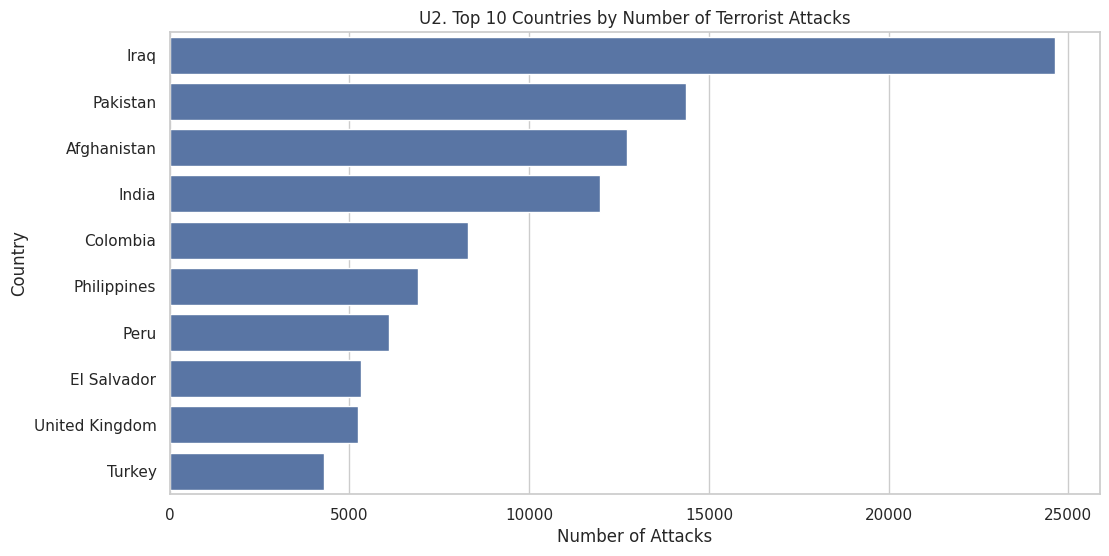

In [19]:

# U2. TOP 10 COUNTRIES BY NUMBER OF ATTACKS

top_10_countries = terror_df['country_txt'].value_counts().head(10)
safe_barplot(
    series_data=top_10_countries,
    title='U2. Top 10 Countries by Number of Terrorist Attacks',
    xlabel='Number of Attacks',
    ylabel='Country'
)

### Why did I pick this chart?
A **horizontal bar chart** is effective for ranking categories with long names and clearly comparing top countries.

### Insight(s) found
- A small number of countries account for a large proportion of total attacks.
- Terrorism is highly concentrated geographically rather than evenly distributed worldwide.

### Business Impact / Negative Growth
Yes, this insight has strong **positive decision-making value**:
- Helps governments and international agencies prioritize **security budgets** and **counter-terrorism operations**.
- Identifies countries that may need stronger intelligence, policing, or humanitarian support.
- High concentration in specific countries indicates **negative growth** in regional stability and can affect investment, tourism, and citizen confidence.

**3. Region-wise Attack Distribution (Pie Chart)**

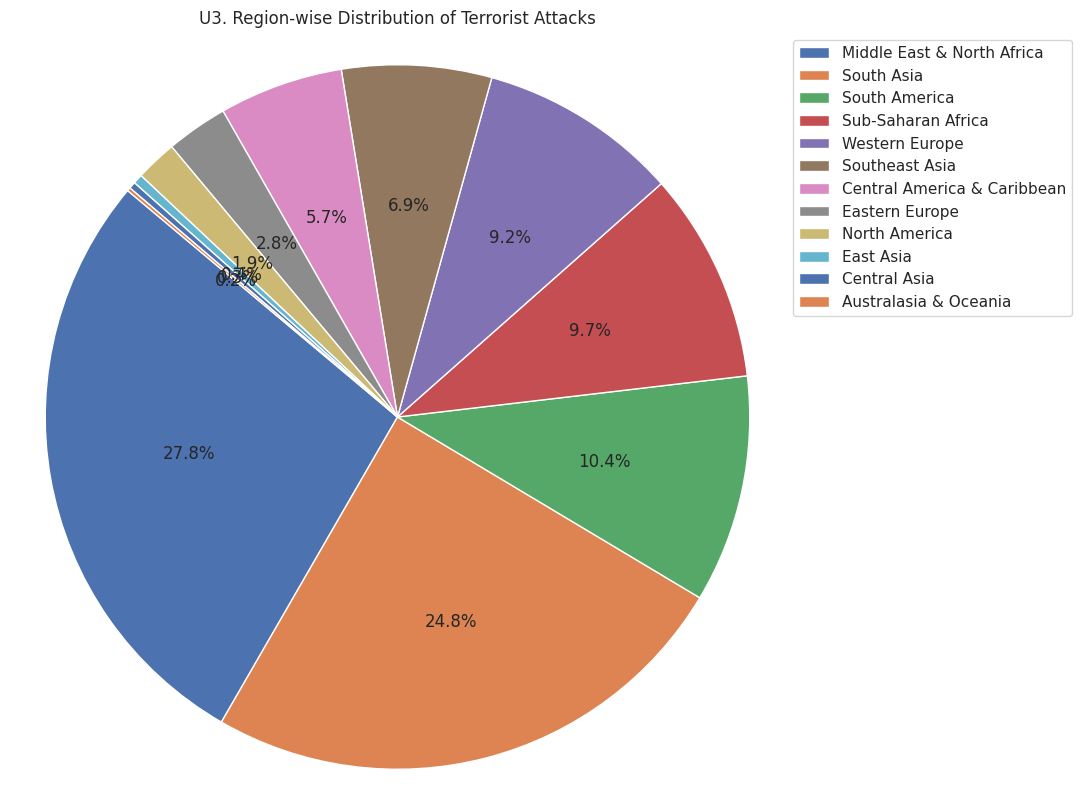

In [76]:
# U3. REGION-WISE DISTRIBUTION OF ATTACKS (PIE CHART)

region_counts = terror_df['region_txt'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(
    region_counts.values,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('U3. Region-wise Distribution of Terrorist Attacks')
plt.axis('equal')

# Optional: cleaner legend instead of labels
plt.legend(region_counts.index, bbox_to_anchor=(1, 1))

plt.show()

### Why did I pick this chart?
A **pie chart** is suitable here because the number of regions is limited, and the goal is to show the **proportion/share of total terrorist attacks** contributed by each region. It helps in understanding how terrorism is distributed globally in percentage terms.

### Insight(s) found
- Terrorist incidents are **not evenly distributed across all regions**.
- A few regions contribute a **large percentage of the total global attacks**.
- This confirms the existence of **clear geopolitical hotspots** where terrorism is heavily concentrated.

### Business Impact / Negative Growth
Yes, this insight creates a **strong positive strategic impact**:
- Governments and international agencies can identify **high-risk regions** and prioritize security resources.
- Humanitarian and emergency organizations can prepare better for regions with larger attack shares.
- A high concentration of attacks in certain regions indicates **negative growth in regional stability**, which can affect trade, tourism, and investment confidence.

**4 . Word Cloud for Countries Involved in Terrorist Incidents**

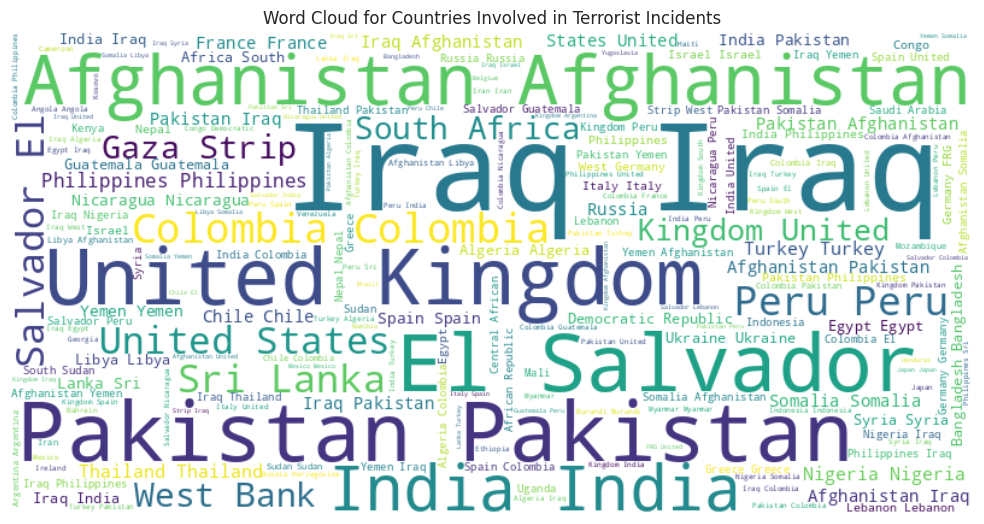

In [21]:
countries_involved = df['country_txt'].dropna()

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(countries_involved))

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Countries Involved in Terrorist Incidents')
plt.axis('off')
plt.tight_layout()
plt.show()

**Why did I pick this chart?**

A word cloud is suitable here because it helps visualize the most frequent words (such as attack types, groups, or keywords) in the dataset. It provides a quick and intuitive understanding of which terms appear most often, with larger words representing higher frequency. This makes it easier to identify dominant patterns in textual data.

**Insight(s) found**

Certain words appear much larger than others, indicating they occur very frequently in the dataset.
This shows that specific attack types, groups, or methods are more dominant compared to others.
It highlights key themes and recurring patterns in terrorism-related data without needing detailed numerical analysis.

**Business Impact / Negative Growth**

Yes, this insight provides meaningful strategic value:

Security agencies can focus on the most common attack types and groups to improve prevention strategies.
Policy makers can design targeted counter-terrorism measures based on frequently occurring threats.
A high frequency of certain violent activities indicates persistent security challenges, which can negatively impact economic stability, tourism, and public safety in affected regions.


**5. Top 10 Attack Types (Donut Chart)**

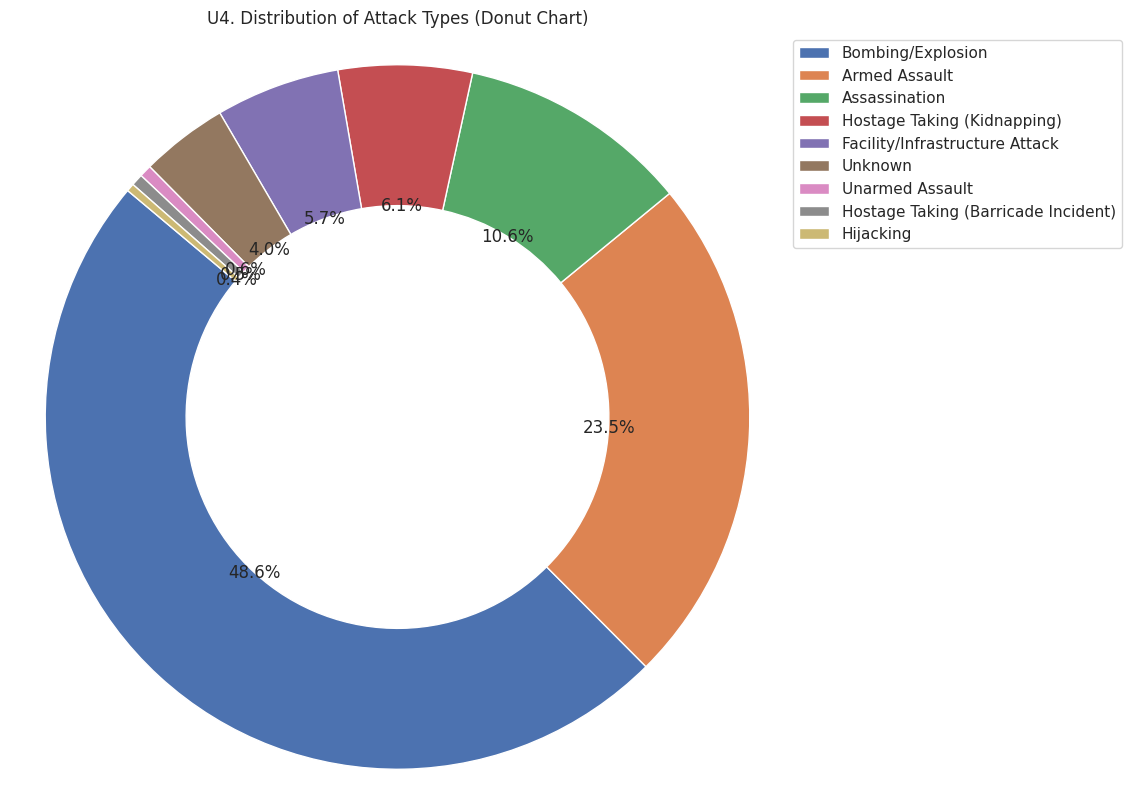

In [75]:
# U4. TOP ATTACK TYPES (DONUT CHART)

attack_counts = terror_df['attacktype1_txt'].value_counts()

plt.figure(figsize=(10, 10))
wedges, texts, autotexts = plt.pie(
    attack_counts.values,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)
)

plt.title('U4. Distribution of Attack Types (Donut Chart)')
plt.axis('equal')

# Optional: add legend instead (cleaner than labels)
plt.legend(attack_counts.index, bbox_to_anchor=(1, 1))

plt.show()

### Why did I pick this chart?
A **donut chart** is ideal for showing the **relative share of different attack types** because the number of categories is manageable and the focus is on composition rather than ranking alone. It also provides a visually appealing alternative to a standard bar chart.

### Insight(s) found
- Certain attack types such as **Bombing/Explosion** and **Armed Assault** contribute a major share of total incidents.
- Terrorist attacks follow **repeated operational patterns** rather than random methods.
- Some attack types are significantly less common, indicating a strong tactical preference.

### Business Impact / Negative Growth
Yes, this insight is highly useful:
- Security agencies can prioritize countermeasures against the **most dominant attack methods**.
- Public infrastructure and event security can be strengthened based on the most common forms of attack.
- If explosive-based attacks dominate, it indicates **negative growth in public-space safety** and raises the need for advanced detection systems.

**6. Top 10 Weapon Types (Pie Chart)**

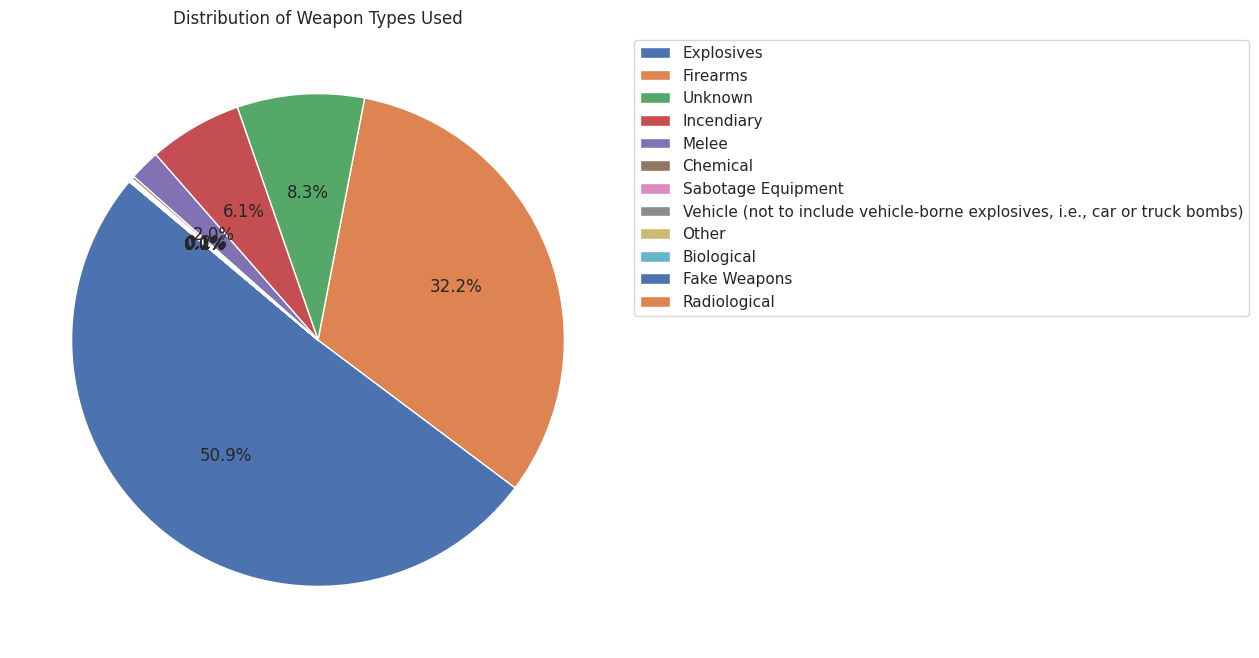

In [74]:
# U5. WEAPON TYPE DISTRIBUTION (PIE CHART)
 plt.figure(figsize=(8,8))
plt.pie(
    weapon_counts.values,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Distribution of Weapon Types Used')

# Add legend separately
plt.legend(weapon_counts.index, bbox_to_anchor=(1,1))
plt.show()

### Why did I pick this chart?
A **pie chart** is appropriate because the number of weapon categories is limited, and it clearly shows the **percentage contribution of each weapon type**. It is effective for understanding the overall composition of weapon usage in terrorist incidents.

### Insight(s) found
- Weapons such as **Explosives** and **Firearms** account for a large share of attacks.
- Terrorist groups appear to rely on a few dominant weapon categories.
- This suggests that weapon choice is influenced by **availability, impact, and tactical efficiency**.

### Business Impact / Negative Growth
Yes, this insight creates important operational value:
- Law enforcement can focus on **screening, tracking, and restricting high-risk weapon categories**.
- Transport hubs, borders, and public venues can strengthen detection mechanisms for commonly used weapons.
- High explosive usage signals **negative growth in civilian safety**, especially in crowded urban environments.

**7. Top 10 Target Types (Bar Chart)**

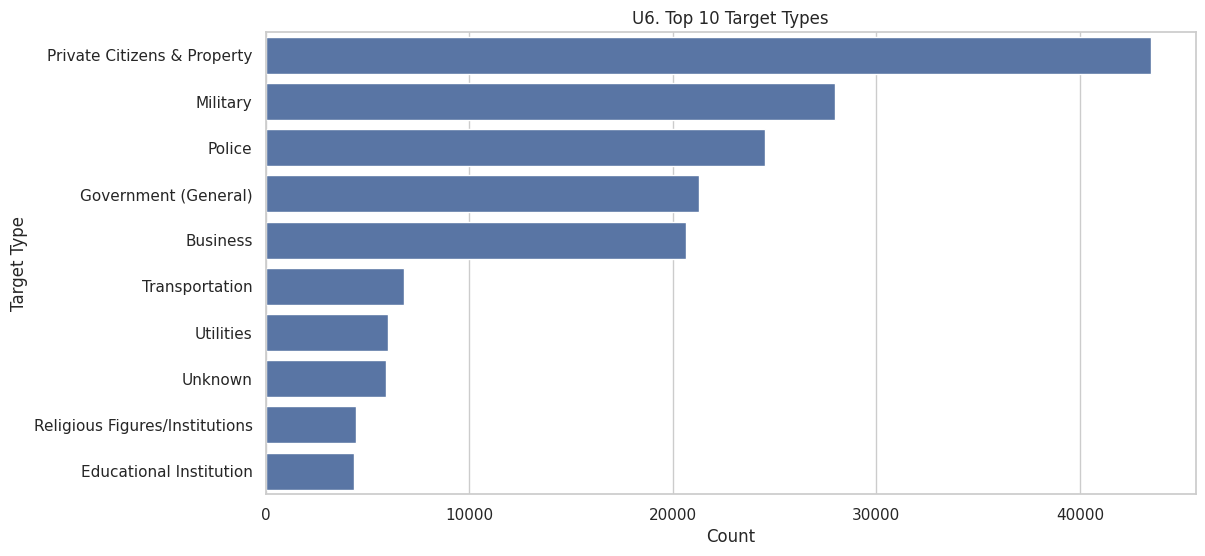

In [24]:

# U6. TOP 10 TARGET TYPES


top_target_types = terror_df['targtype1_txt'].value_counts().head(10)
safe_barplot(
    series_data=top_target_types,
    title='U6. Top 10 Target Types',
    xlabel='Count',
    ylabel='Target Type'
)

### Why did I pick this chart?
A **bar chart** helps rank target categories and identify which groups or institutions are most frequently attacked.

### Insight(s) found
- Some target categories (e.g., private citizens, police, military, government) are attacked more often.
- This reveals who is most exposed and vulnerable.

### Business Impact / Negative Growth
Yes:
- Helps governments strengthen protection around the most frequently targeted institutions.
- Private-sector organizations can improve **risk management and contingency planning**.
- High attacks on civilians or critical institutions signal **negative social and economic stability**.

**8. Word Cloud for types of targets Involved in Terrorist Incidents**

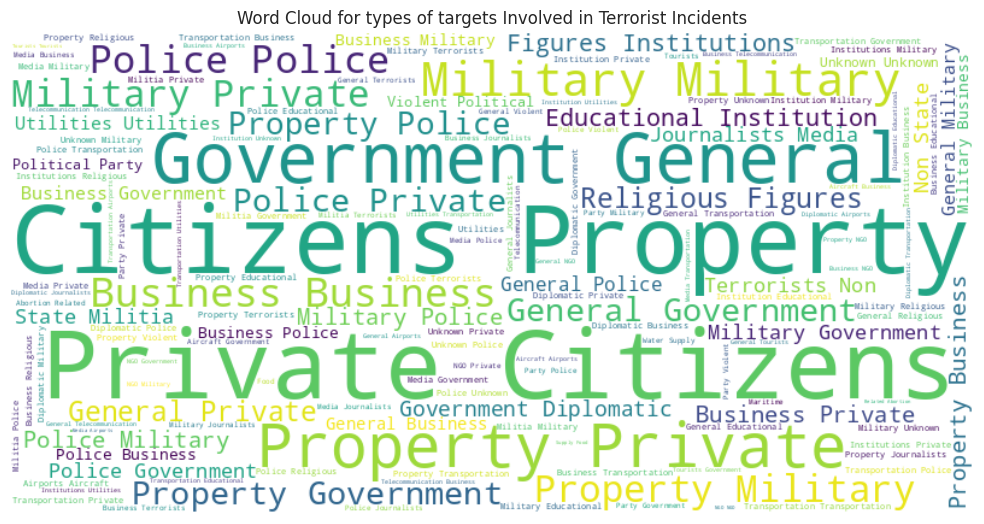

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

target_type = df['targtype1_txt'].dropna()

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(target_type))

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for types of targets Involved in Terrorist Incidents')
plt.axis('off')
plt.tight_layout()
plt.show()

**Why did I pick this chart?**  
A Word Cloud is suitable here because it visualizes the most frequent target types involved in terrorist incidents. It helps in quickly identifying which types of targets (such as civilians, military, government, etc.) are most commonly affected. Larger words represent higher frequency, making dominant target categories easy to spot.

**Insight(s) found**  
The Word Cloud shows that certain target types appear more prominently, indicating they are more frequently attacked.  
This suggests that terrorist activities are focused on specific categories of targets rather than being evenly distributed.  
It highlights key vulnerable sectors such as civilians, security forces, or infrastructure.

**Business Impact / Negative Growth**  
Yes, this insight provides strong strategic value:  
Governments can strengthen security measures around the most targeted sectors.  
Law enforcement agencies can prioritize protection strategies for high-risk target types.  
Frequent attacks on critical or civilian targets indicate instability, which can negatively affect public safety, economic activities, and overall development.

**9. Success vs Failure of Attacks (Count Plot)**

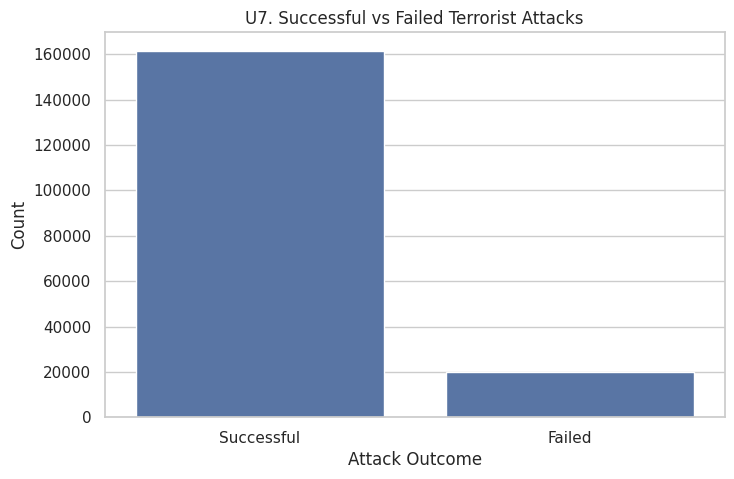

In [26]:

# U7. SUCCESSFUL VS FAILED ATTACKS

safe_countplot(
    data=terror_df,
    x_col='success_label',
    title='U7. Successful vs Failed Terrorist Attacks',
    xlabel='Attack Outcome',
    ylabel='Count',
    figsize=(8, 5)
)

### Why did I pick this chart?
A **count plot** is the most direct way to compare the frequency of two categorical outcomes: successful vs failed attacks.

### Insight(s) found
- A large share of incidents are often recorded as successful.
- This indicates that many attacks reached at least partial execution.

### Business Impact / Negative Growth
Yes:
- This is highly important for intelligence and prevention strategy.
- A high success ratio indicates **negative growth in preventive security systems**.
- It suggests a need for better surveillance, faster response, and stronger threat interception mechanisms.

**10.  Comparison of People Wounded and Killed Each Year**

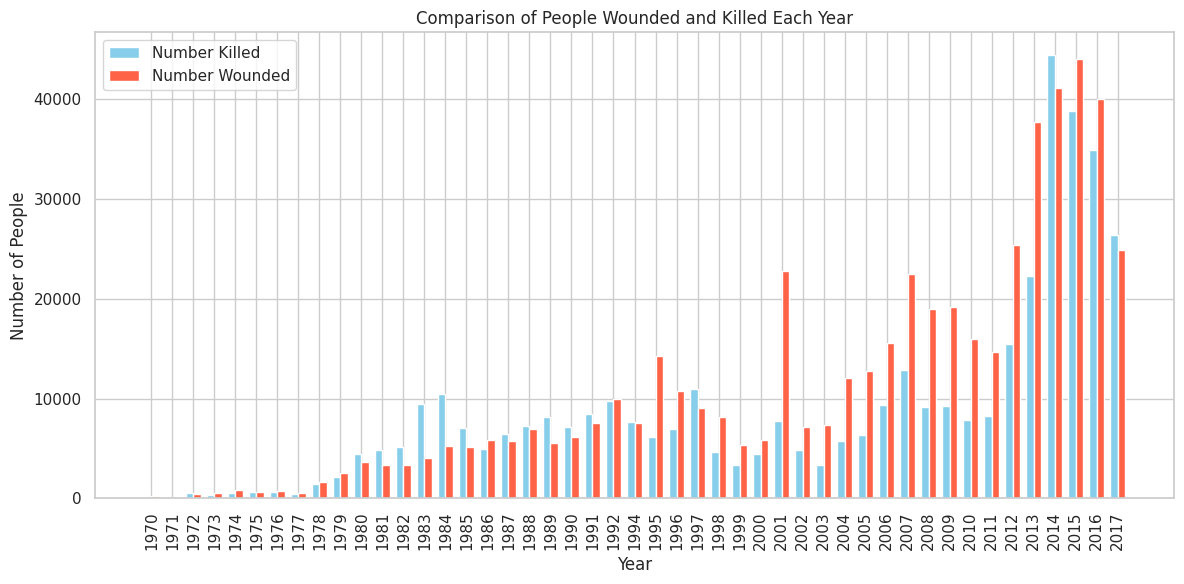

In [27]:
yearly_casualties = df.groupby('iyear')[['nkill', 'nwound']].sum()

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(yearly_casualties))

plt.bar(index, yearly_casualties['nkill'], bar_width, label='Number Killed', color='skyblue')
plt.bar(index + bar_width, yearly_casualties['nwound'], bar_width, label='Number Wounded', color='Tomato')

plt.xlabel('Year')
plt.ylabel('Number of People')
plt.title('Comparison of People Wounded and Killed Each Year')
plt.xticks(index + bar_width / 2, yearly_casualties.index, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

**B — BIVARIATE ANALYSIS (8 CHARTS)**

**11. Top 10 Countries by Total Casualties (Bar Chart)**

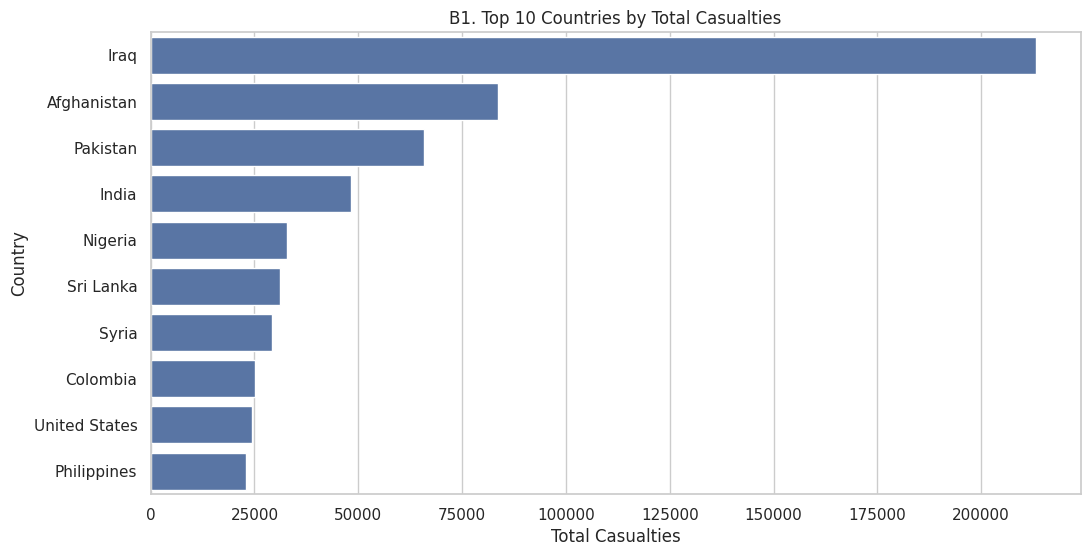

In [28]:

# B1. TOP 10 COUNTRIES BY TOTAL CASUALTIES


country_casualties = terror_df.groupby('country_txt')['casualties'].sum().sort_values(ascending=False).head(10)

safe_barplot(
    series_data=country_casualties,
    title='B1. Top 10 Countries by Total Casualties',
    xlabel='Total Casualties',
    ylabel='Country'
)

### Why did I pick this chart?
A **bar chart** is ideal for comparing total casualties across countries and highlighting severity, not just frequency.

### Insight(s) found
- Some countries may not only have many attacks but also much higher human impact.
- This separates **high-frequency regions** from **high-severity regions**.

### Business Impact / Negative Growth
Yes:
- Helps prioritize **medical preparedness**, emergency response, and humanitarian support.
- Countries with high casualty totals require stronger crisis management systems.
- High casualty concentration reflects **negative growth in human security and public resilience**.

**12. Average Casualties by Attack Type (Top 10) (Boxplot)**

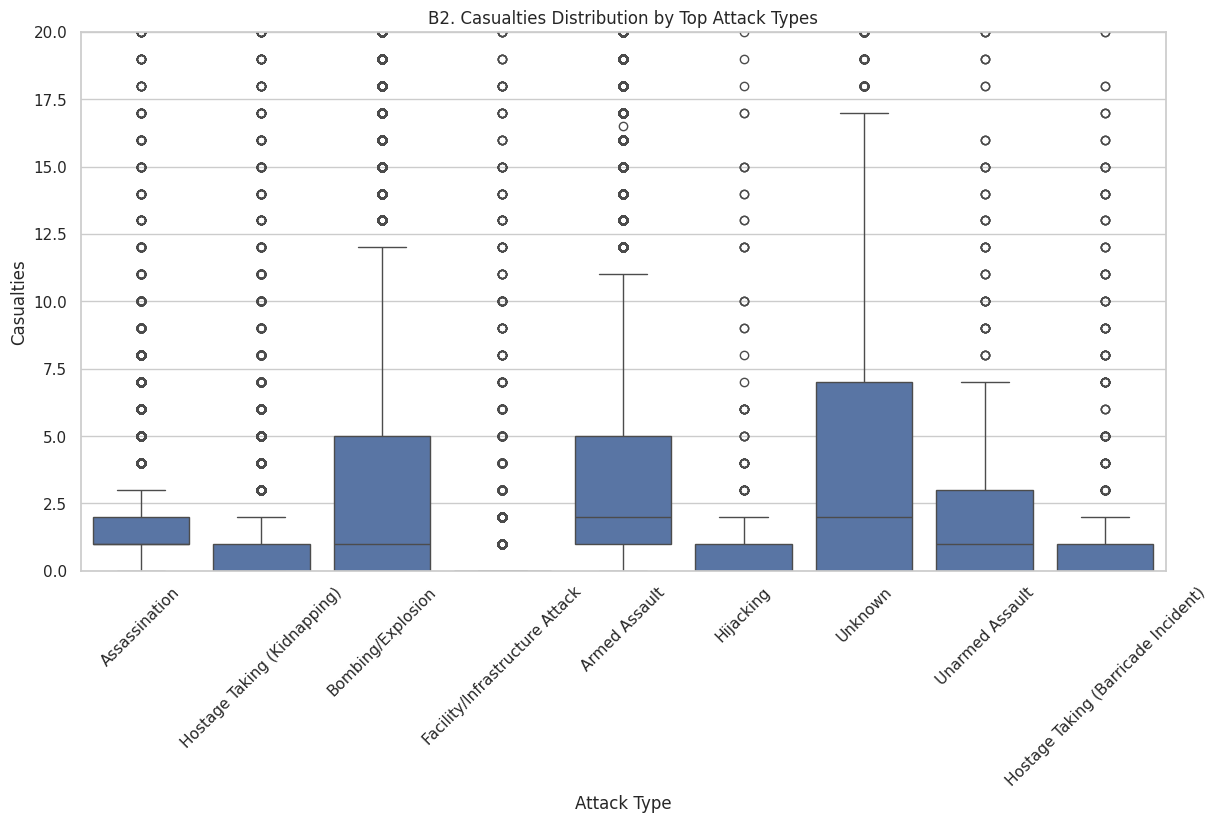

In [29]:
# B2. CASUALTIES DISTRIBUTION BY TOP ATTACK TYPES (BOXPLOT)

top_10_attack_labels = terror_df['attacktype1_txt'].value_counts().head(10).index
attack_box_df = terror_df[terror_df['attacktype1_txt'].isin(top_10_attack_labels)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=attack_box_df, x='attacktype1_txt', y='casualties')
plt.title('B2. Casualties Distribution by Top Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Casualties')
plt.xticks(rotation=45)
plt.ylim(0, attack_box_df['casualties'].quantile(0.95))
plt.show()

### Why did I pick this chart?
A **box plot** is more suitable than a bar chart here because it shows the **distribution of casualties** across attack types, not just the average. It reveals the median, spread, skewness, and outliers, making it more informative for severity analysis.

### Insight(s) found
- Some attack types may have a **low median casualty count** but contain **extreme high-casualty outliers**.
- Certain attack types are not only frequent but also **more severe and unpredictable** in human impact.
- The distribution shows that attack severity varies widely even within the same attack category.

### Business Impact / Negative Growth
Yes, this insight is highly actionable:
- Stakeholders can identify which attack types create the **greatest casualty variability and extreme risk**.
- Emergency medical systems can be better prepared for attack types that have potential for **mass-casualty incidents**.
- Attack types with large outliers indicate **negative growth in humanitarian safety**, as even infrequent events can cause devastating losses.

**13. Average Casualties by Weapon Type (Top 10) (Violin Plot)**

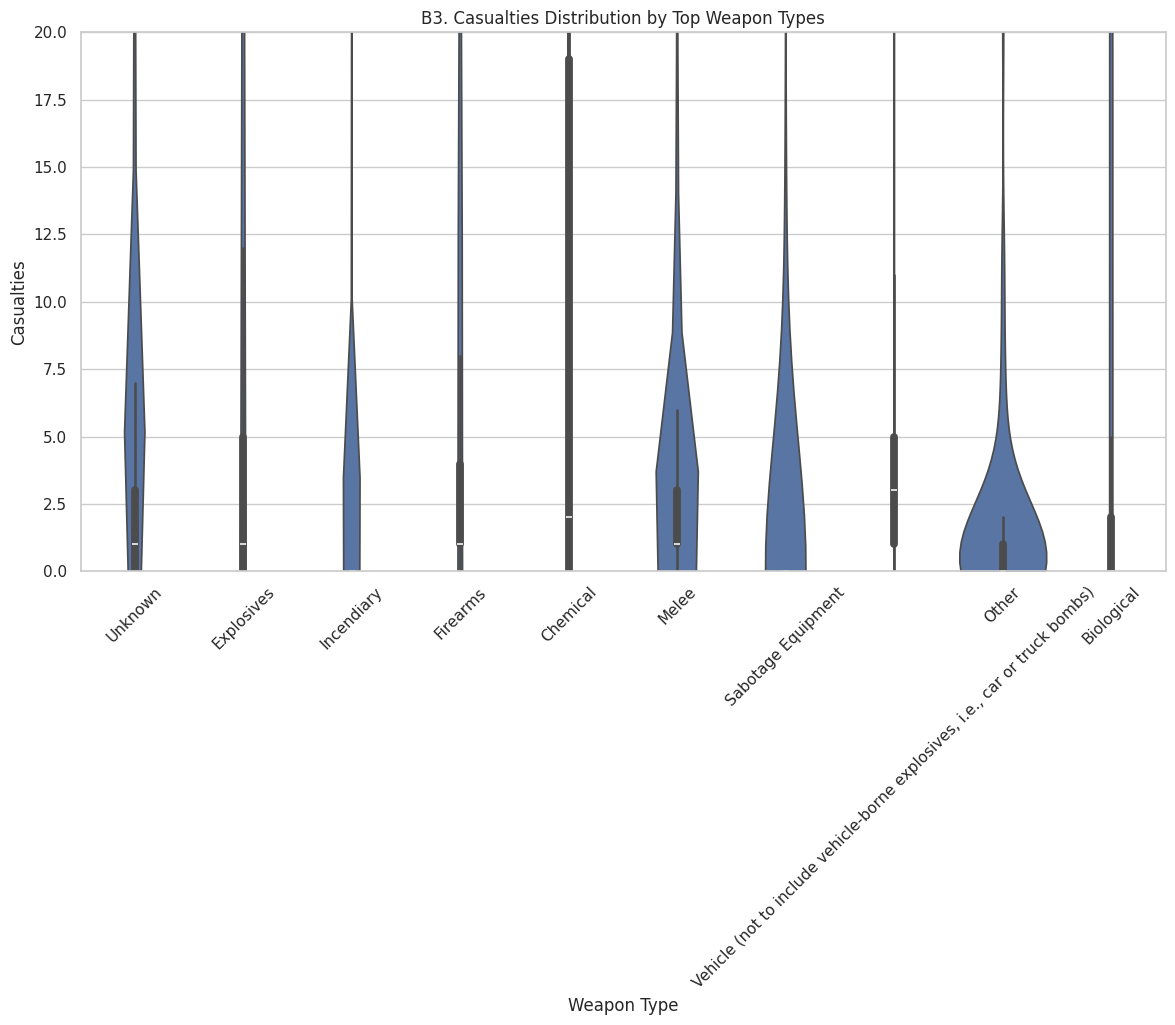

In [30]:
# B3. CASUALTIES DISTRIBUTION BY TOP WEAPON TYPES (VIOLIN PLOT)

top_10_weapon_labels = terror_df['weaptype1_txt'].value_counts().head(10).index
weapon_violin_df = terror_df[terror_df['weaptype1_txt'].isin(top_10_weapon_labels)]

plt.figure(figsize=(14, 7))
sns.violinplot(data=weapon_violin_df, x='weaptype1_txt', y='casualties')
plt.title('B3. Casualties Distribution by Top Weapon Types')
plt.xlabel('Weapon Type')
plt.ylabel('Casualties')
plt.xticks(rotation=45)
plt.ylim(0, weapon_violin_df['casualties'].quantile(0.95))
plt.show()

### Why did I pick this chart?
A **violin plot** is ideal because it shows the **full distribution and density of casualties** for each weapon type. Compared to a bar chart, it provides deeper insight into whether casualties are concentrated around lower values or spread across a wider range.

### Insight(s) found
- Some weapon types have **tighter distributions**, meaning they usually cause similar casualty levels.
- Other weapon types show **wider and more spread-out distributions**, indicating more unpredictable severity.
- Certain weapons may be less frequent but still associated with **higher casualty potential**.

### Business Impact / Negative Growth
Yes, this insight is very useful:
- Helps authorities prioritize prevention and response for **high-impact weapon categories**.
- Emergency response teams can develop **weapon-specific casualty preparedness strategies**.
- Weapons with wide or extreme casualty distributions indicate **negative growth in public safety resilience**, especially where response capacity is limited.

**14. Success Rate by Attack Type (Bar Chart)**

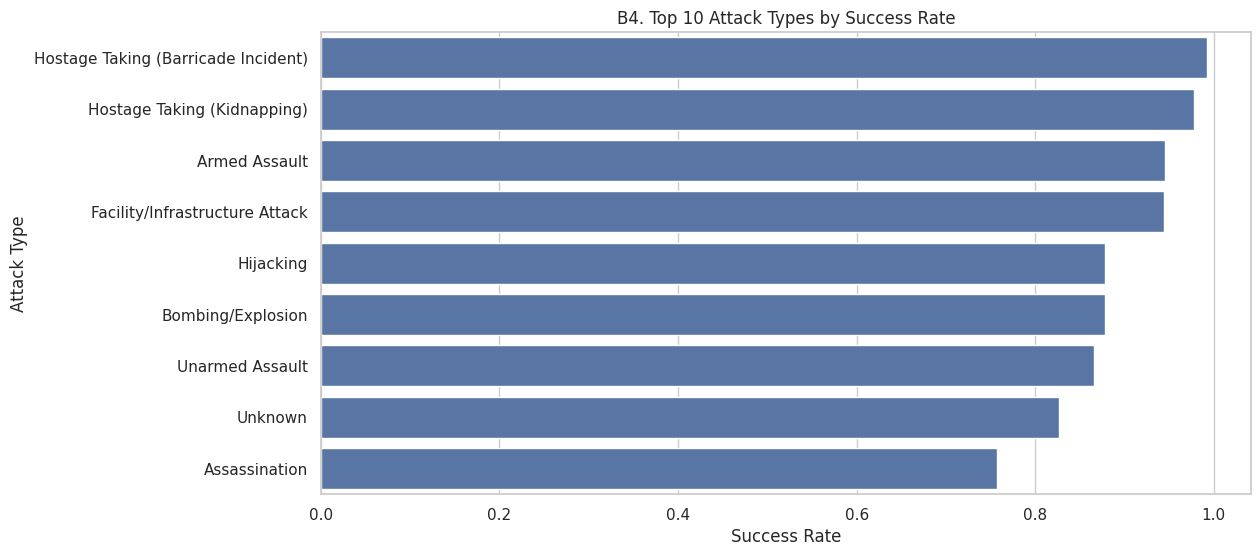

In [31]:

# B4. SUCCESS RATE BY ATTACK TYPE


# Compute average of binary success column => success rate
success_rate_attack = (
    terror_df.groupby('attacktype1_txt')['success']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

safe_barplot(
    series_data=success_rate_attack,
    title='B4. Top 10 Attack Types by Success Rate',
    xlabel='Success Rate',
    ylabel='Attack Type'
)

### Why did I pick this chart?
A **bar chart** is excellent for comparing success rates across categories.

### Insight(s) found
- Some attack types are more operationally successful than others.
- This may reflect ease of execution, accessibility, or lower detection risk.

### Business Impact / Negative Growth
Yes:
- Helps prioritize preventive systems against the attack types most likely to succeed.
- Supports targeted upgrades in surveillance and law enforcement training.
- High success rates indicate **negative growth in defensive effectiveness**.

**15. Property Damage vs Attack Outcome (Count Plot)**

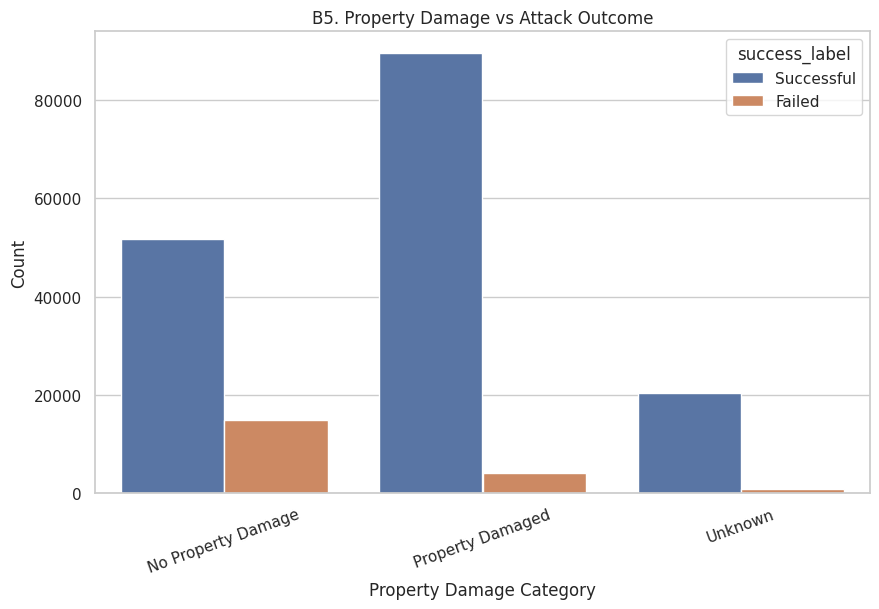

In [32]:

# B5. PROPERTY DAMAGE VS ATTACK OUTCOME

plt.figure(figsize=(10, 6))
sns.countplot(data=terror_df, x='property_label', hue='success_label')
plt.title('B5. Property Damage vs Attack Outcome')
plt.xlabel('Property Damage Category')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

### Why did I pick this chart?
A **count plot with hue** is useful for comparing how attack outcomes vary across property damage categories.

### Insight(s) found
- Successful attacks are more likely to be associated with property damage.
- Property damage can serve as an indicator of attack severity and operational impact.

### Business Impact / Negative Growth
Yes:
- Helps insurers, infrastructure planners, and governments assess **asset vulnerability**.
- Supports protection of critical infrastructure and urban resilience planning.
- High property damage linked to successful attacks signals **negative economic growth pressure** through reconstruction costs and investor uncertainty.

**16. Monthly Distribution of Attacks (Line Chart)**

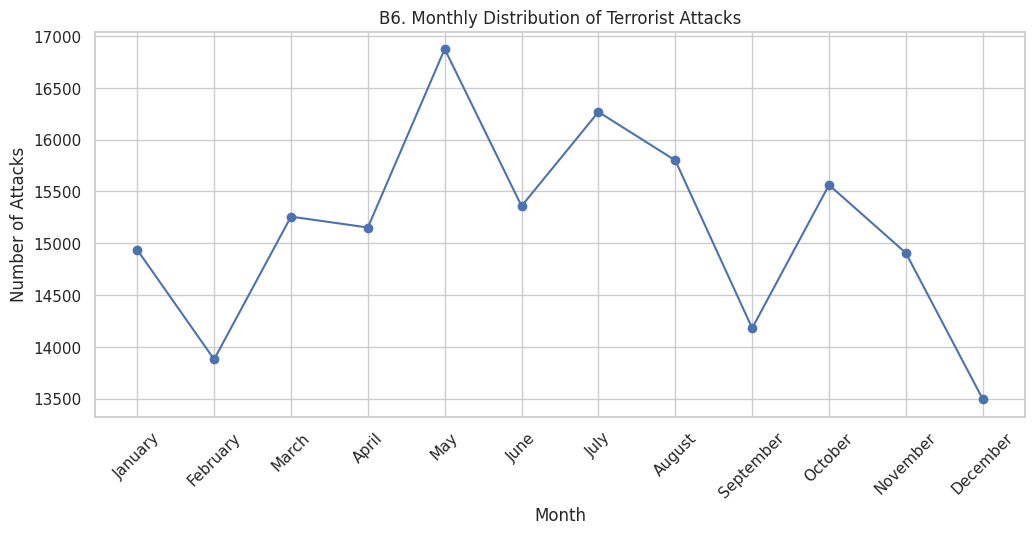

In [33]:
# B6. MONTHLY DISTRIBUTION OF ATTACKS (LINE CHART)

monthly_counts = terror_df['month_name'].value_counts()

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_counts = monthly_counts.reindex(month_order).dropna()

plt.figure(figsize=(12, 5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')
plt.title('B6. Monthly Distribution of Terrorist Attacks')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45)
plt.show()

### Why did I pick this chart?
A **line chart** is better than a bar chart here because months follow a **natural sequential order**, and the goal is to identify **seasonal patterns or fluctuations** across the year. It makes changes from one month to the next easier to interpret.

### Insight(s) found
- Terrorist incidents may show **seasonal concentration**, with some months experiencing more attacks than others.
- This may reflect the influence of **political cycles, festivals, conflicts, weather, or major public events**.
- The trend helps identify months where security risk may be relatively higher.

### Business Impact / Negative Growth
Yes, this creates strong planning value:
- Governments and security agencies can increase vigilance during **high-risk months**.
- Public event organizers can improve safety planning during periods with historically higher activity.
- Seasonal spikes indicate **temporary negative growth in public safety**, which can impact tourism, transport, and mass gatherings.

**17. Top 10 Groups by Number of Attacks (Lollipop Chart)**

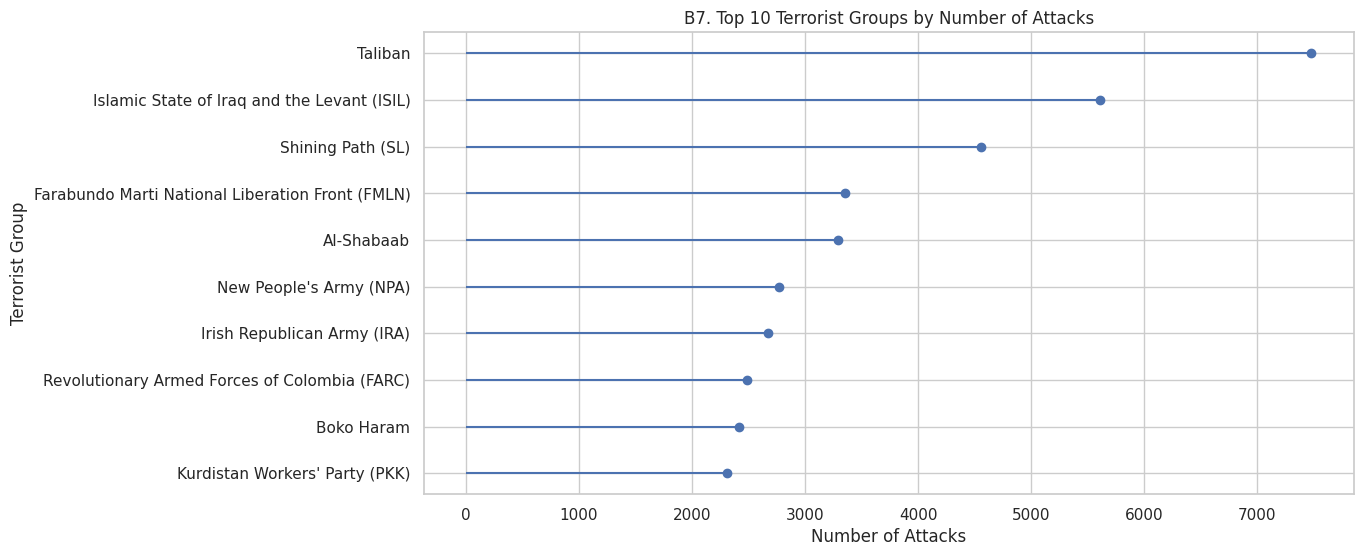

In [34]:
# B7. TOP 10 TERRORIST GROUPS BY NUMBER OF ATTACKS (LOLLIPOP CHART)

top_groups = terror_df[terror_df['gname'] != 'Unknown']['gname'].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 6))
plt.hlines(y=top_groups.index, xmin=0, xmax=top_groups.values)
plt.plot(top_groups.values, top_groups.index, "o")
plt.title('B7. Top 10 Terrorist Groups by Number of Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Terrorist Group')
plt.show()

### Why did I pick this chart?
A **lollipop chart** is a visually clean and modern alternative to a bar chart for ranking categories. It highlights the difference between top terrorist groups while reducing visual clutter and making comparisons easier.

### Insight(s) found
- A small number of terrorist groups are responsible for a **disproportionately high number of attacks**.
- Threat activity is concentrated among **repeat and highly active actors**.
- This shows that terrorism risk is often driven by a limited set of organizations rather than being evenly spread across all groups.

### Business Impact / Negative Growth
Yes, this insight has major intelligence value:
- Security agencies can prioritize **surveillance, intelligence gathering, and targeted disruption** against the most active groups.
- Helps optimize limited counter-terrorism resources toward the highest-impact organizations.
- Persistent dominance by a few groups reflects **negative growth in threat containment and deterrence**.

**18. Correlation Between Killed, Wounded, Casualties, Success (Heatmap)**

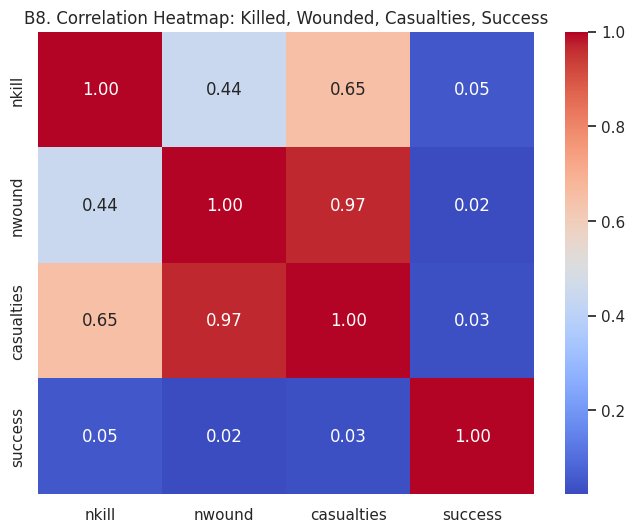

In [35]:

# B8. CORRELATION HEATMAP (NUMERICAL-NUMERICAL)


corr_cols = ['nkill', 'nwound', 'casualties', 'success']
corr_matrix = terror_df[corr_cols].corr()

safe_heatmap(
    corr_df=corr_matrix,
    title='B8. Correlation Heatmap: Killed, Wounded, Casualties, Success'
)

### Why did I pick this chart?
A **heatmap** is the best way to visualize pairwise correlations among numerical variables in a compact format.

### Insight(s) found
- **casualties** strongly correlates with **nkill** and **nwound**, as expected.
- The relationship between success and casualties may be weaker than expected, showing that success does not always mean high casualties.

### Business Impact / Negative Growth
Yes:
- Helps analysts understand which metrics move together and which do not.
- Useful for designing future risk scoring systems and predictive models.
- If successful attacks do not always imply high casualties, stakeholders must avoid oversimplified risk assumptions.

**M — MULTIVARIATE ANALYSIS (6 CHARTS)**

**19. Top 10 Countries by Attacks, Colored by Average Casualties (Bar Chart)**

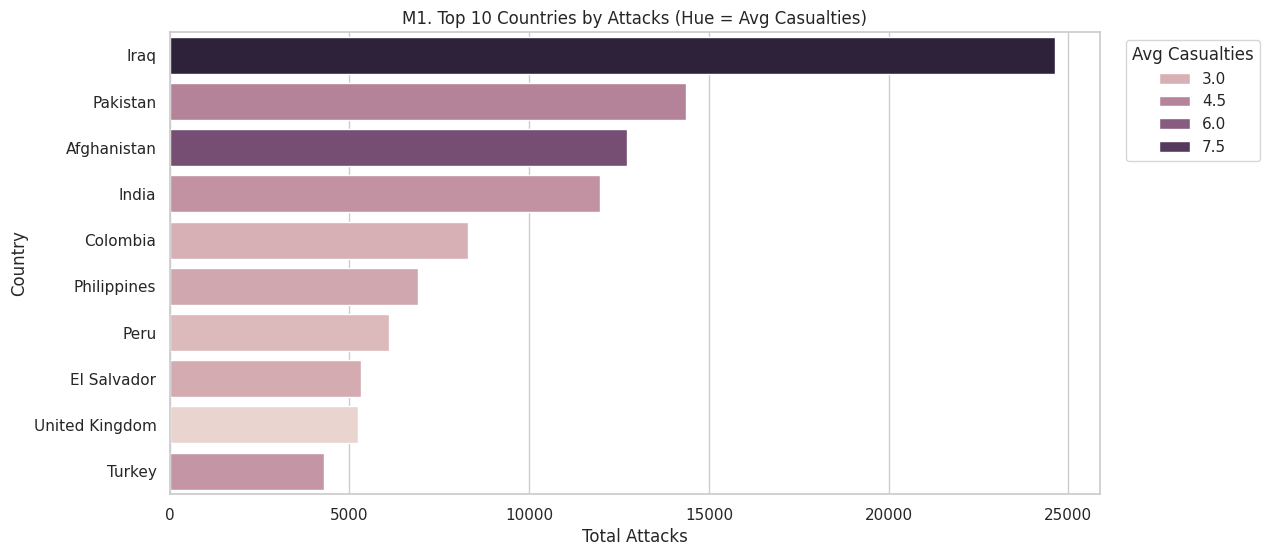

In [36]:

# M1. TOP 10 COUNTRIES BY ATTACK COUNT + AVG CASUALTIES

country_attack_count = terror_df['country_txt'].value_counts().head(10).index

country_multi = (
    terror_df[terror_df['country_txt'].isin(country_attack_count)]
    .groupby('country_txt')
    .agg(
        total_attacks=('country_txt', 'count'),
        avg_casualties=('casualties', 'mean')
    )
    .sort_values('total_attacks', ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_multi, x='total_attacks', y='country_txt', hue='avg_casualties', dodge=False)
plt.title('M1. Top 10 Countries by Attacks (Hue = Avg Casualties)')
plt.xlabel('Total Attacks')
plt.ylabel('Country')
plt.legend(title='Avg Casualties', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### Why did I pick this chart?
This is a **multivariate bar chart** because it combines:
- Country
- Total attacks
- Average casualties (as hue)

It helps compare both frequency and severity together.

### Insight(s) found
- Some countries have very high attack counts but moderate average casualties.
- Others may have fewer attacks but higher average severity.

### Business Impact / Negative Growth
Yes:
- This helps distinguish **high-frequency risk** from **high-severity risk**.
- Governments can prioritize resources differently: prevention for high-frequency areas, trauma response for high-severity areas.
- Countries with both high attacks and high casualties reflect **serious negative growth in security resilience**.

**20. Yearly Total Casualties Trend (Area Chart)**

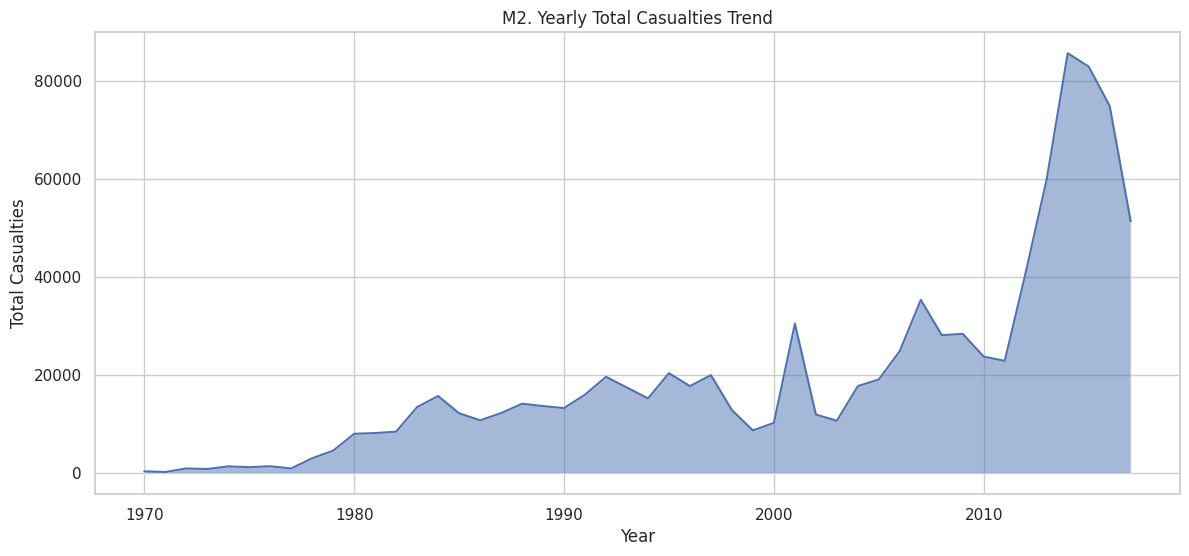

In [37]:
# M2. YEARLY TOTAL CASUALTIES TREND (AREA CHART)

yearly_casualties = terror_df.groupby('iyear')['casualties'].sum()

plt.figure(figsize=(14, 6))
plt.fill_between(yearly_casualties.index, yearly_casualties.values, alpha=0.5)
plt.plot(yearly_casualties.index, yearly_casualties.values)
plt.title('M2. Yearly Total Casualties Trend')
plt.xlabel('Year')
plt.ylabel('Total Casualties')
plt.show()

### Why did I pick this chart?
An **area chart** is well-suited for showing how the **total human impact** changes over time because it emphasizes both the **trend and the magnitude** of casualties. It is especially useful when the volume of impact is important, not just the direction of change.

### Insight(s) found
- Total casualties fluctuate significantly over the years, with some years showing **major spikes in human impact**.
- The years with the highest number of attacks are not always the same as the years with the highest casualties.
- This proves that **frequency and severity are different dimensions of risk**.

### Business Impact / Negative Growth
Yes, this insight is strategically important:
- Governments and hospitals can use this information to improve **medical readiness and disaster-response capacity**.
- Helps distinguish between years of high attack volume and years of high humanitarian loss.
- Spikes in casualties indicate **negative growth in public safety and resilience**, even if attack frequency is not at its peak.

### Why did I pick this chart?
A **line chart** is ideal for tracking how the total human impact changes over time.

### Insight(s) found
- Attack frequency and casualty severity do not always rise together.
- Some years may have fewer attacks but much higher casualties, indicating more severe incidents.

### Business Impact / Negative Growth
Yes:
- Helps separate **volume risk** from **severity risk**.
- Supports better emergency preparedness and hospital readiness.
- Years with spikes in casualties indicate **negative growth in humanitarian safety**, even if attack counts are not at their peak.

**21. Total Casualties by Attack Type and Region**

<Figure size 1600x1200 with 0 Axes>

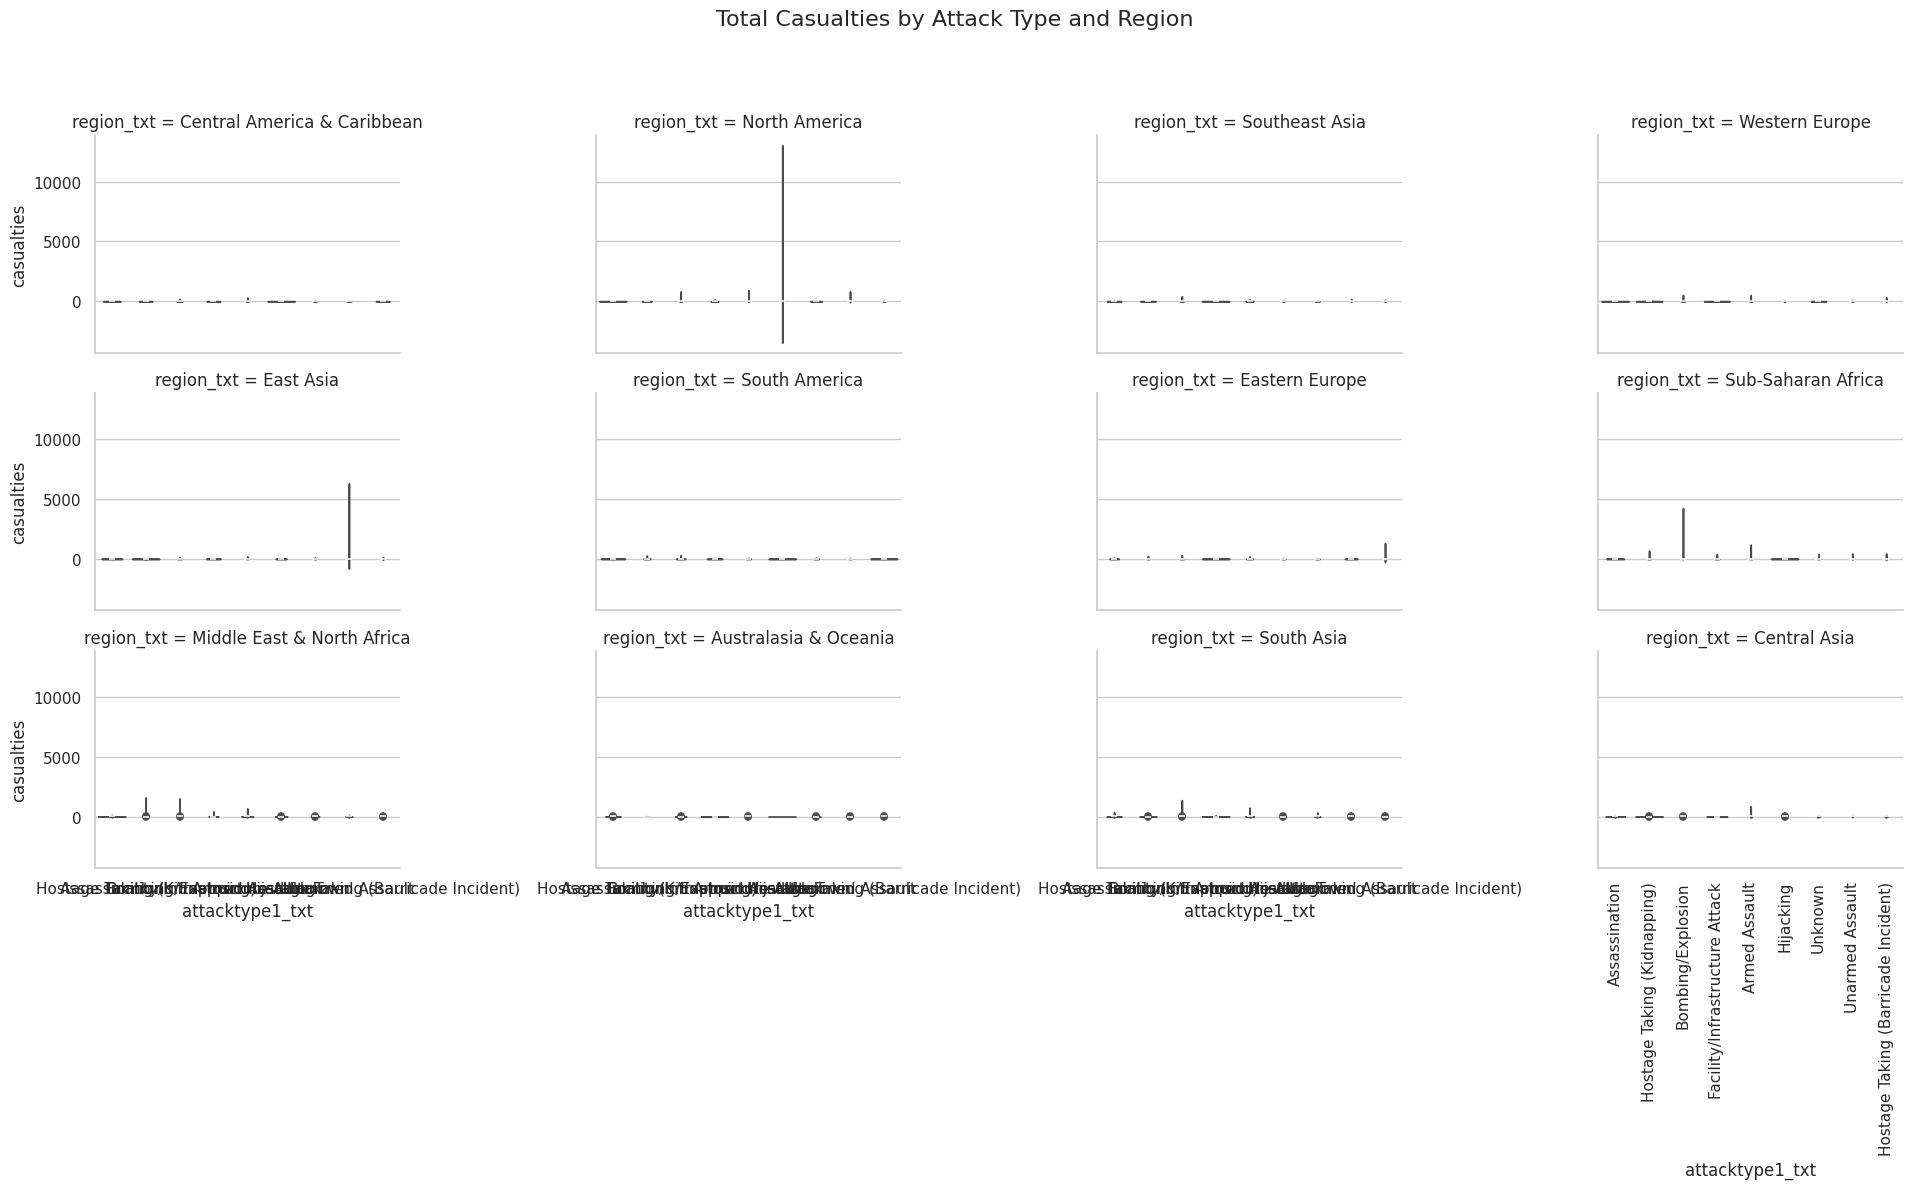

In [38]:
plt.figure(figsize=(16, 12))
sns.catplot(x='attacktype1_txt', y='casualties', col='region_txt', data=terror_df, kind='violin', col_wrap=4, height=4, aspect=1.2, sharey=True)
plt.suptitle('Total Casualties by Attack Type and Region', y=1.02, fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

**Why did I pick this chart?**  
A violin plot is suitable here because it shows the distribution of total casualties across different attack types while also comparing patterns across regions. It combines the features of a box plot and density plot, allowing us to understand not just the average impact but also the spread and variability of casualties. Faceting by region helps in analyzing how attack impacts differ geographically.

**Insight(s) found**  
The distribution of casualties varies significantly across different attack types.  
Some attack types show a wider spread, indicating inconsistent but potentially very high casualty events.  
There are noticeable regional differences, where certain regions experience higher or more variable casualties for specific attack types.  
This highlights that both the type of attack and the region play a crucial role in determining the severity of incidents.

**Business Impact / Negative Growth**  
Yes, this insight provides strong strategic value:  
Governments and security agencies can identify which attack types cause the most damage in specific regions and allocate resources accordingly.  
Emergency response systems can be better prepared for high-impact attack types in vulnerable regions.  
Regions with high variability and extreme casualty events indicate instability, which can negatively affect economic growth, tourism, and investment confidence.

**22. Top 10 Countries × Success Rate (Bar Chart)**

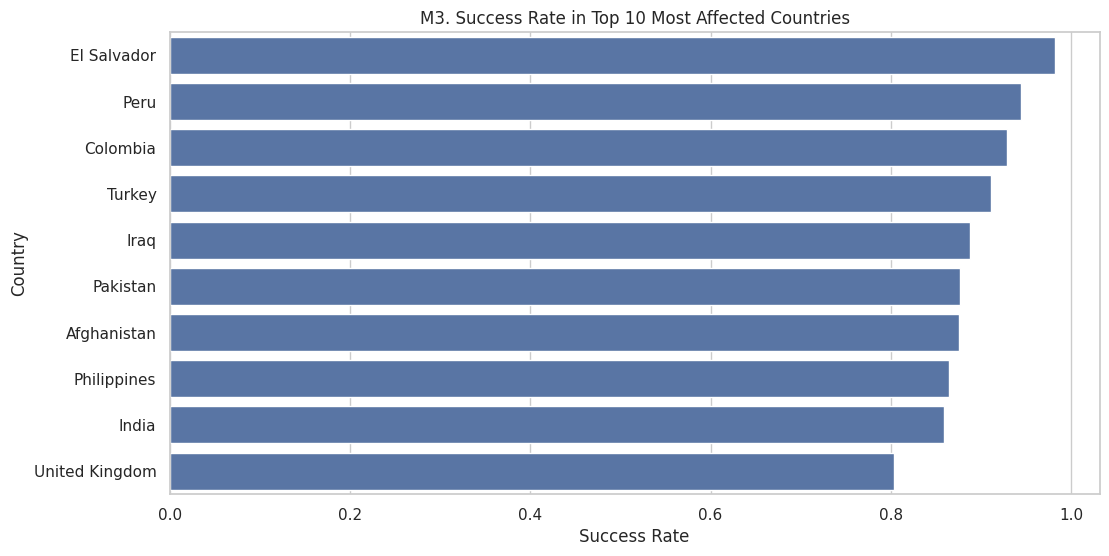

In [39]:

# M3. SUCCESS RATE IN TOP 10 MOST AFFECTED COUNTRIES

top_10_country_names = terror_df['country_txt'].value_counts().head(10).index

country_success_rate = (
    terror_df[terror_df['country_txt'].isin(top_10_country_names)]
    .groupby('country_txt')['success']
    .mean()
    .sort_values(ascending=False)
)

safe_barplot(
    series_data=country_success_rate,
    title='M3. Success Rate in Top 10 Most Affected Countries',
    xlabel='Success Rate',
    ylabel='Country'
)

### Why did I pick this chart?
This chart compares **country** and **success rate**, linking geography with operational outcome.

### Insight(s) found
- Some high-incident countries also show high success rates.
- This may indicate stronger attacker adaptation or weaker preventive systems in those locations.

### Business Impact / Negative Growth
Yes:
- Helps governments identify where attacks are not only frequent but also more likely to succeed.
- This is highly actionable for improving intelligence, rapid response, and infrastructure security.
- High success rates in high-attack countries indicate **negative growth in operational defense effectiveness**.

**23. Attack Type × Weapon Type (Top 10 combinations) (Heatmap)**

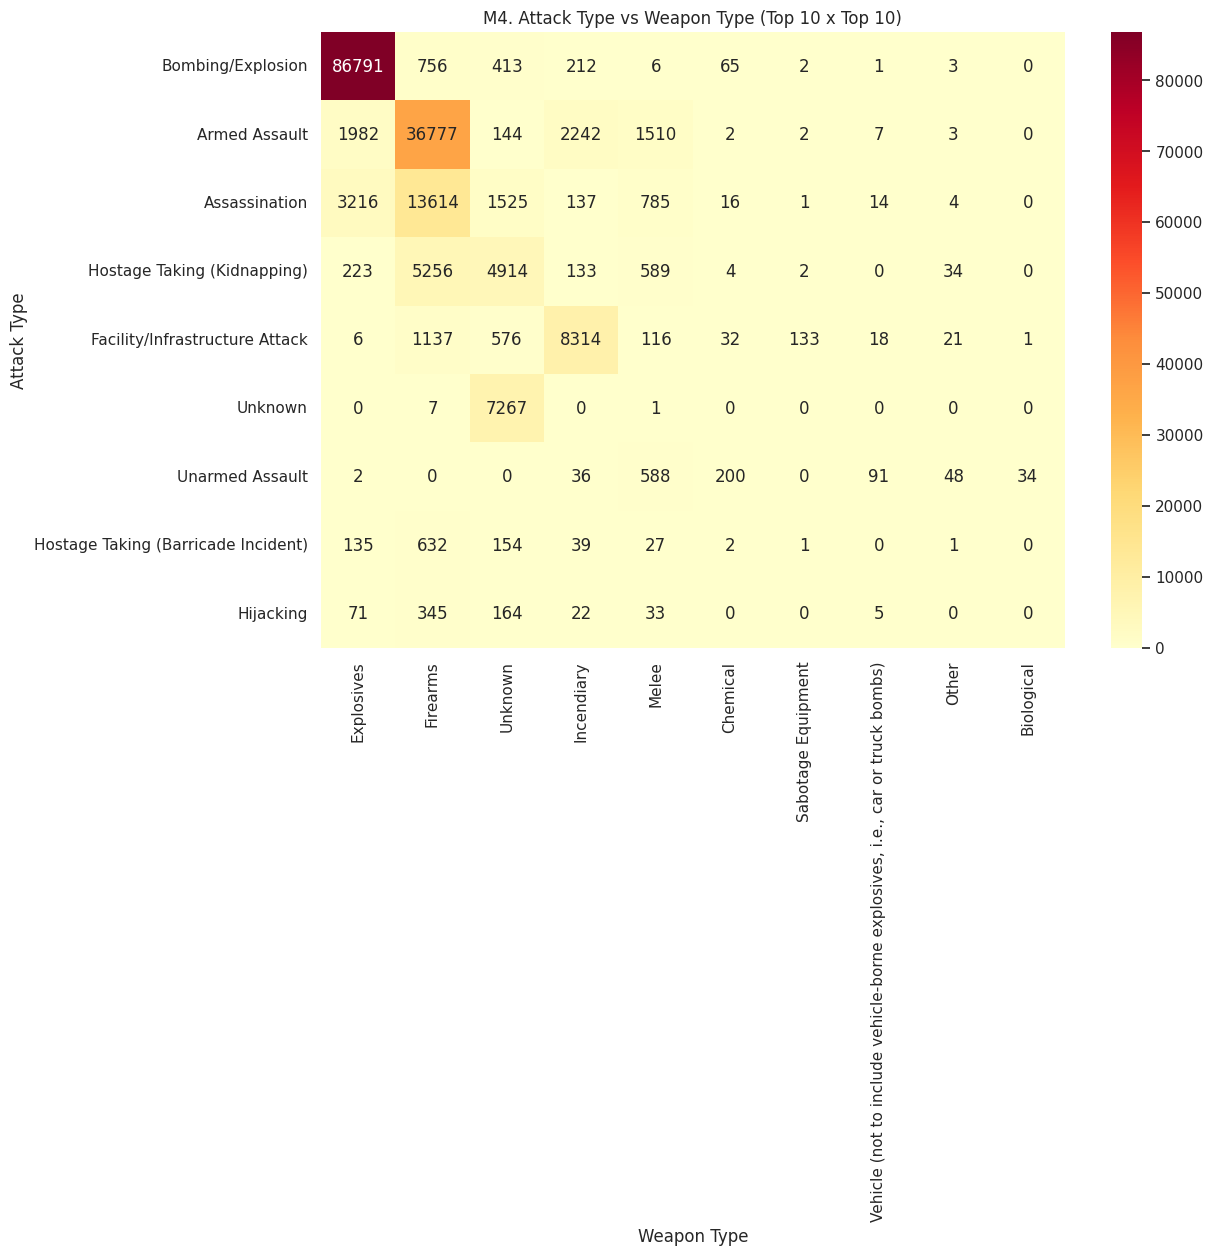

In [40]:

# M4. ATTACK TYPE VS WEAPON TYPE (TOP COMBINATIONS)

# Create crosstab of attack type and weapon type
attack_weapon_ct = pd.crosstab(terror_df['attacktype1_txt'], terror_df['weaptype1_txt'])

# Reduce to top 10 attack types and top 10 weapon types for readability
top_attack_rows = terror_df['attacktype1_txt'].value_counts().head(10).index
top_weapon_cols = terror_df['weaptype1_txt'].value_counts().head(10).index

attack_weapon_ct_small = attack_weapon_ct.loc[top_attack_rows, top_weapon_cols]

plt.figure(figsize=(12, 8))
sns.heatmap(attack_weapon_ct_small, annot=True, fmt='d', cmap='YlOrRd')
plt.title('M4. Attack Type vs Weapon Type (Top 10 x Top 10)')
plt.xlabel('Weapon Type')
plt.ylabel('Attack Type')
plt.show()

### Why did I pick this chart?
A **heatmap** is ideal for visualizing interaction intensity between two categorical variables.

### Insight(s) found
- Certain attack types are strongly associated with specific weapon types.
- This reveals tactical pairings such as bombings with explosives or assaults with firearms.

### Business Impact / Negative Growth
Yes:
- Extremely useful for **threat pattern recognition** and targeted preventive measures.
- Helps transportation hubs, public venues, and law enforcement plan screening based on likely combinations.
- Strong recurring tactical combinations indicate **negative growth in attack pattern predictability being exploited by adversaries**.

**24. Region-wise Avg Casualties vs Success Rate (Bubble Chart)**

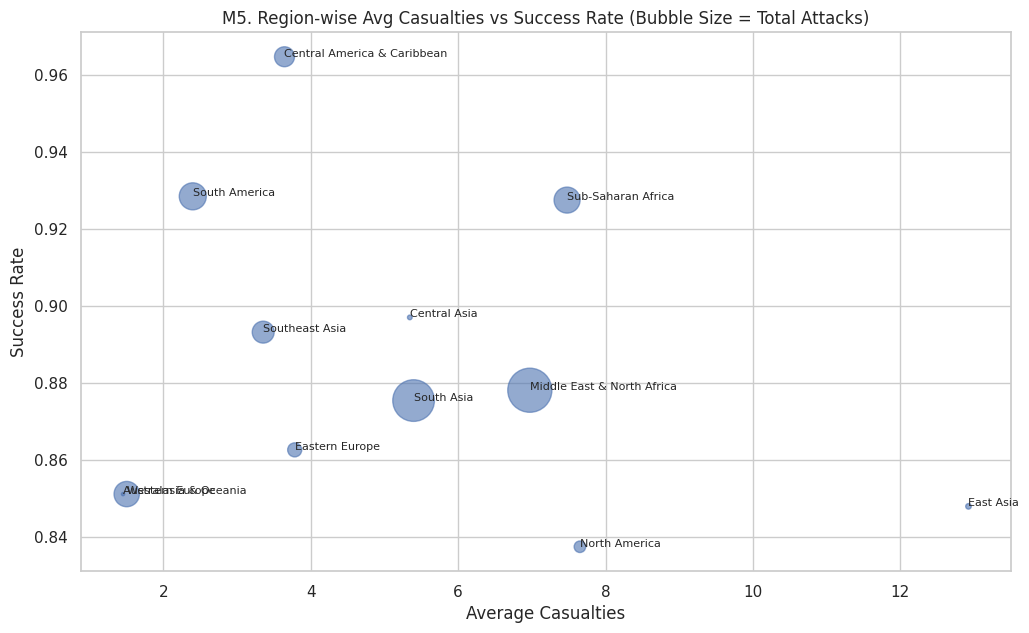

In [41]:
# M5. REGION-WISE MULTIVARIATE BUBBLE CHART

region_multi = (
    terror_df.groupby('region_txt')
    .agg(
        avg_casualties=('casualties', 'mean'),
        success_rate=('success', 'mean'),
        total_attacks=('region_txt', 'count')
    )
    .reset_index()
)

plt.figure(figsize=(12, 7))
plt.scatter(
    region_multi['avg_casualties'],
    region_multi['success_rate'],
    s=region_multi['total_attacks'] / 50,
    alpha=0.6
)

for i in range(len(region_multi)):
    plt.text(
        region_multi['avg_casualties'].iloc[i],
        region_multi['success_rate'].iloc[i],
        region_multi['region_txt'].iloc[i],
        fontsize=8
    )

plt.title('M5. Region-wise Avg Casualties vs Success Rate (Bubble Size = Total Attacks)')
plt.xlabel('Average Casualties')
plt.ylabel('Success Rate')
plt.show()

### Why did I pick this chart?
A **bubble chart** is ideal for multivariate analysis because it allows three variables to be shown at once:
- **X-axis:** Average casualties
- **Y-axis:** Success rate
- **Bubble size:** Total attacks

This makes it a true multivariate visualization and helps compare **frequency, severity, and operational effectiveness** together.

### Insight(s) found
- Some regions have **high attack frequency** but moderate average casualties.
- Other regions may have **fewer attacks but much higher average casualties**.
- Regions with both **large bubble size, high success rate, and high average casualties** are the most critical risk zones.

### Business Impact / Negative Growth
Yes, this insight is extremely valuable:
- Helps international agencies distinguish between **high-volume risk regions** and **high-severity risk regions**.
- Supports better allocation of resources for prevention, emergency response, and humanitarian intervention.
- Regions combining high success and high severity indicate **serious negative growth in regional security stability**.

**25. Top 10 Groups: Attack Count vs Average Casualties (Scatter Plot)**

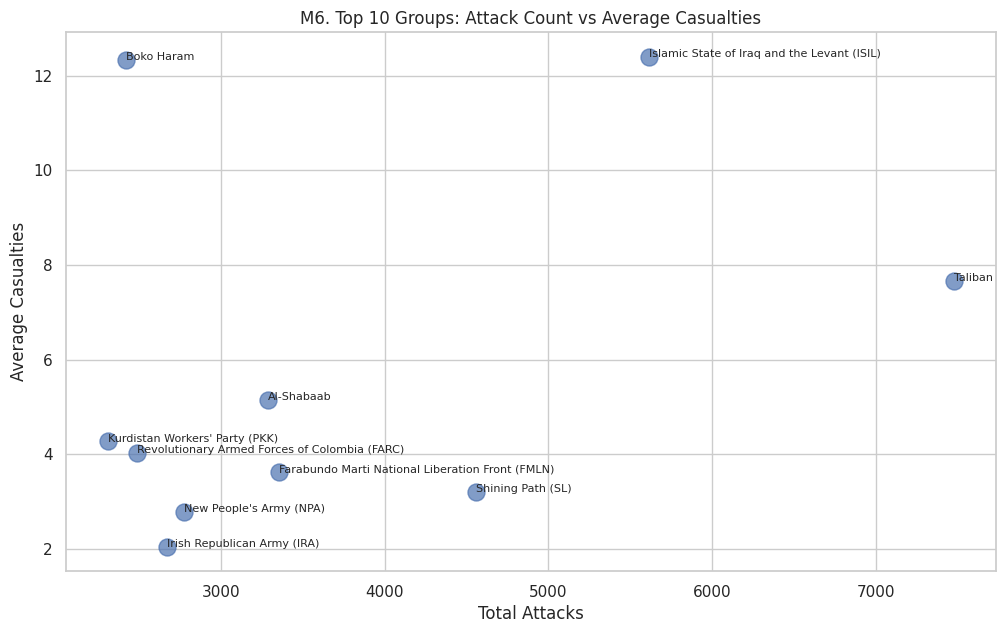

In [42]:
# M6. TOP 10 GROUPS: ATTACK COUNT VS AVG CASUALTIES (SCATTER PLOT)

top_10_group_names = terror_df[terror_df['gname'] != 'Unknown']['gname'].value_counts().head(10).index

group_multi = (
    terror_df[terror_df['gname'].isin(top_10_group_names)]
    .groupby('gname')
    .agg(
        total_attacks=('gname', 'count'),
        avg_casualties=('casualties', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(12, 7))
plt.scatter(group_multi['total_attacks'], group_multi['avg_casualties'], s=150, alpha=0.7)

for i in range(len(group_multi)):
    plt.text(
        group_multi['total_attacks'].iloc[i],
        group_multi['avg_casualties'].iloc[i],
        group_multi['gname'].iloc[i],
        fontsize=8
    )

plt.title('M6. Top 10 Groups: Attack Count vs Average Casualties')
plt.xlabel('Total Attacks')
plt.ylabel('Average Casualties')
plt.show()

### Why did I pick this chart?
A **scatter plot** is ideal because it compares two quantitative measures for each terrorist group:
- **Total attacks**
- **Average casualties**

This helps identify whether the most active groups are also the most deadly, which is more informative than a simple bar chart.

### Insight(s) found
- Some groups carry out **many attacks but have lower average casualties per incident**.
- Other groups may be **less frequent but much more severe** on average.
- This shows that **activity level and deadliness are not always the same**, which is a crucial strategic distinction.

### Business Impact / Negative Growth
Yes, this insight is highly actionable:
- Intelligence agencies can build a more nuanced **threat ranking system** instead of focusing only on attack counts.
- Helps prioritize groups that are either **highly active, highly deadly, or both**.
- Groups that combine high frequency and high average casualties represent **severe negative growth in national and international security**.

##** SOME IMPORTANT INSIGHTS

**Top 10 Cities by Attacks**

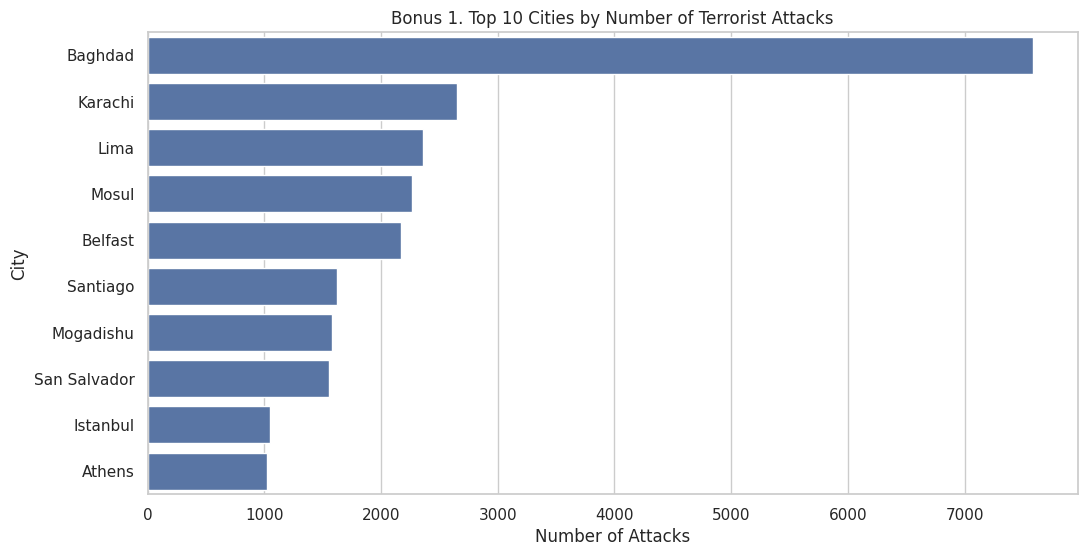

In [43]:
#  TOP 10 CITIES BY ATTACKS

top_cities = terror_df[terror_df['city'] != 'Unknown']['city'].value_counts().head(10)

safe_barplot(
    series_data=top_cities,
    title='Bonus 1. Top 10 Cities by Number of Terrorist Attacks',
    xlabel='Number of Attacks',
    ylabel='City'
)

**Distribution of Casualties (0–100 range)**

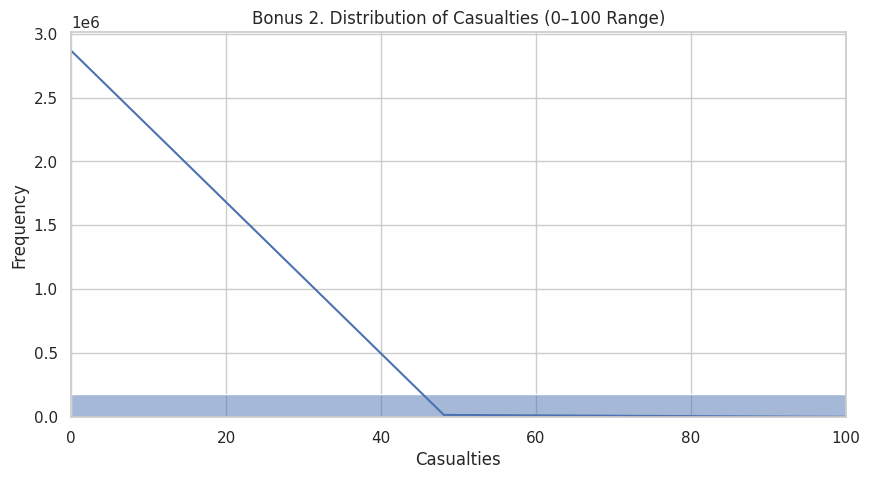

In [44]:
# DISTRIBUTION OF CASUALTIES (FOCUSED RANGE)

safe_histplot(
    data=terror_df,
    col='casualties',
    title='Bonus 2. Distribution of Casualties (0–100 Range)',
    xlabel='Casualties',
    ylabel='Frequency',
    bins=50,
    xlim=(0, 100)
)

1. Which year had the highest number of attacks?

In [45]:
year_attacks = terror_df['iyear'].value_counts().sort_index()
peak_year = year_attacks.idxmax()
peak_attacks = year_attacks.max()

print("Year with highest number of attacks:", peak_year)
print("Number of attacks:", peak_attacks)

Year with highest number of attacks: 2014
Number of attacks: 16903


2. Which country had the highest number of attacks?

In [46]:
top_country = terror_df['country_txt'].value_counts().head(1)
print("Country with highest attacks:\n")
print(top_country)

Country with highest attacks:

country_txt
Iraq    24636
Name: count, dtype: int64


3. Which region is most affected?

In [47]:
top_region = terror_df['region_txt'].value_counts().head(1)
print("Most affected region:\n")
print(top_region)

Most affected region:

region_txt
Middle East & North Africa    50474
Name: count, dtype: int64


4. Most common attack type

In [48]:
top_attack_type = terror_df['attacktype1_txt'].value_counts().head(1)
print("Most common attack type:\n")
print(top_attack_type)

Most common attack type:

attacktype1_txt
Bombing/Explosion    88255
Name: count, dtype: int64


5. Most commonly used weapon type

In [49]:
top_weapon = terror_df['weaptype1_txt'].value_counts().head(1)
print("Most commonly used weapon type:\n")
print(top_weapon)

Most commonly used weapon type:

weaptype1_txt
Explosives    92426
Name: count, dtype: int64


6. Terrorist group with highest attacks

In [50]:
top_group = terror_df[terror_df['gname'] != 'Unknown']['gname'].value_counts().head(1)
print("Terrorist group with highest attacks:\n")
print(top_group)

Terrorist group with highest attacks:

gname
Taliban    7478
Name: count, dtype: int64


7. Top 10 countries by total casualties

In [51]:
country_casualties = terror_df.groupby('country_txt')['casualties'].sum().sort_values(ascending=False)
print("Top 10 countries by casualties:\n")
print(country_casualties.head(10))

Top 10 countries by casualties:

country_txt
Iraq             213279.0
Afghanistan       83661.0
Pakistan          65860.0
India             48321.0
Nigeria           32921.0
Sri Lanka         31091.0
Syria             29338.0
Colombia          25026.0
United States     24473.0
Philippines       22926.0
Name: casualties, dtype: float64


## Hypothesis Testing Analysis
Hypothesis testing was conducted on the Global Terrorism Dataset to statistically validate key relationships and patterns observed during exploratory data analysis. This step ensures that the insights derived are not based on random variation but are supported by statistical evidence. Three hypothesis tests were performed to analyze different types of relationships within the dataset.

First, an independent two-sample **t-test** was used to examine whether there is a significant difference in the number of casualties between successful and failed terrorist attacks. The results indicated that successful attacks tend to result in higher casualties, highlighting the severity and impact of successful operations.

Second, a **Chi-square test of independence** was applied to evaluate the relationship between weapon type and attack success. This test is particularly suitable because both variables are categorical. The findings suggested that attack success is not independent of weapon type, meaning that certain weapons are more likely to lead to successful outcomes. This insight is crucial for understanding operational patterns and potential risks.

Third, a **correlation test (Pearson correlation)** was performed between the number of people killed and the number of people wounded. The analysis revealed a positive correlation, indicating that incidents with higher fatalities are also likely to have higher numbers of injuries. This reflects the overall severity of attacks and helps in assessing their impact.

Overall, these hypothesis tests provide a deeper statistical understanding of the dataset by validating relationships between critical variables. The results are valuable for stakeholders such as policymakers and security agencies, as they support data-driven decision-making, improve risk assessment, and help in designing more effective counter-terrorism strategies.

##1. T-Test Visualization (Independent Two-Sample T-Test): **Casualties vs Attack Success**

### Why did I choose this method?
The independent two-sample t-test is used to compare the means of a numerical variable across two different groups. In the context of the Global Terrorism Dataset, this method is appropriate for analyzing whether there is a statistically significant difference in casualties between successful and failed attacks. Since the target variable (success) is binary and casualties is numerical, the t-test provides a reliable way to evaluate differences between these two groups.

### Insight(s) found
The t-test helps determine whether observed differences in average casualties are statistically significant or due to random variation. By comparing the means of the two groups, it provides a clear understanding of whether attack success is associated with higher impact in terms of casualties. It also helps validate patterns identified during exploratory data analysis.

### Business Impact / Negative Growth
This method supports data-driven decision-making by identifying whether successful attacks are more severe. If a significant difference is found, it indicates higher risk associated with successful attacks, which can help in improving emergency response planning. It also highlights potential negative growth in global security, as higher casualties reflect increased severity of terrorist activities.

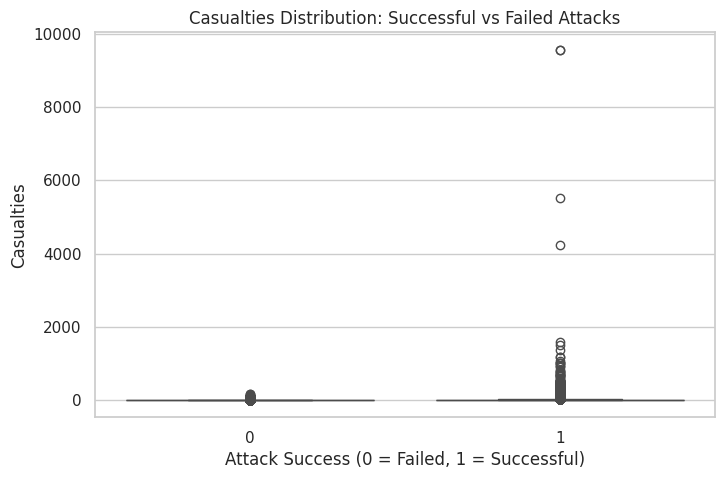

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='success', y='casualties', data=terror_df)
plt.title("Casualties Distribution: Successful vs Failed Attacks")
plt.xlabel("Attack Success (0 = Failed, 1 = Successful)")
plt.ylabel("Casualties")
plt.show()

### Why did I pick this chart?
A **boxplot** is ideal for comparing distributions between two groups. It clearly shows median, spread, and outliers, making it suitable for analyzing differences in casualties between successful and failed attacks.

### Insight(s) found
- Successful attacks generally show **higher median casualties**.
- The spread of casualties is wider for successful attacks, indicating higher variability.
- Presence of extreme outliers suggests that some attacks are significantly more severe.

### Business Impact / Negative Growth
Yes, this insight is highly impactful:
- Helps identify that successful attacks lead to **greater damage and risk**.
- Supports **emergency preparedness and response planning**.
- Indicates **increasing severity of attacks**, which reflects negative growth in global security conditions.

##2. Chi-Square Visualization(Test of Independence) : **Weapon Type vs Attack Success**

### Why did I choose this method?
The Chi-square test of independence is used to determine whether there is a relationship between two categorical variables. In this dataset, it is ideal for analyzing the relationship between weapon type and attack success. Since both variables are categorical, this test helps evaluate whether the distribution of successful and failed attacks varies across different weapon types.

### Insight(s) found
The Chi-square test helps identify whether weapon type plays a significant role in determining attack success. It shows whether certain weapon categories are more likely to result in successful attacks. This provides insight into patterns and dependencies within the dataset, helping to uncover relationships that are not immediately visible.

### Business Impact / Negative Growth
This analysis is highly valuable for stakeholders as it helps identify high-risk weapon types. Security agencies can use this information to focus on monitoring and controlling specific weapons. If a strong dependency is observed, it indicates vulnerabilities in handling certain attack methods, which may contribute to negative growth in security conditions and require targeted interventions.

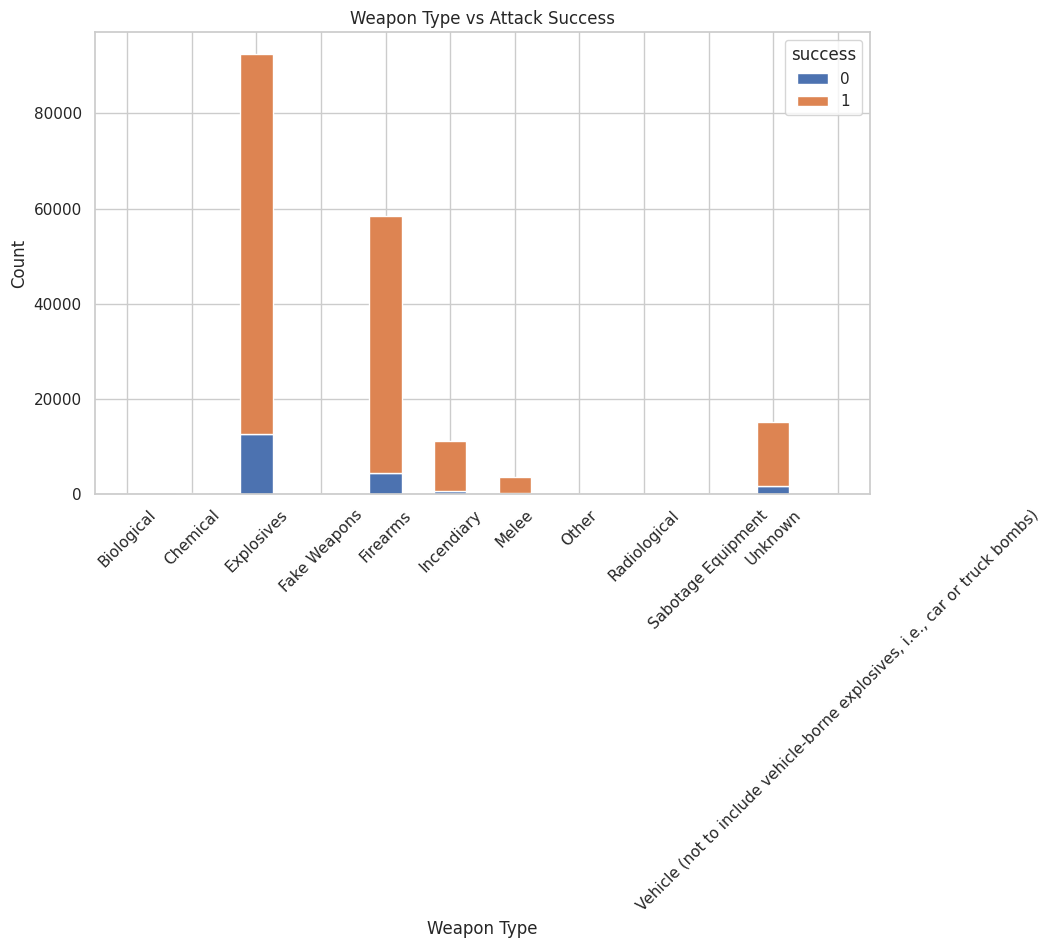

In [72]:
weapon_success = pd.crosstab(terror_df['weaptype1_txt'], terror_df['success'])

weapon_success.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Weapon Type vs Attack Success")
plt.xlabel("Weapon Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Why did I pick this chart?
A **stacked bar chart** is effective for comparing categorical variables. It shows how attack success is distributed across different weapon types.

### Insight(s) found
- Certain weapon types have a higher proportion of successful attacks.
- Some weapons show more failed attempts, indicating lower effectiveness.
- Clear variation exists in success rates across weapon categories.

### Business Impact / Negative Growth
Yes, this insight is critical:
- Helps identify **high-risk weapon types**.
- Supports development of **targeted security measures and regulations**.
- Enables better **threat detection systems**.
- High success rates of certain weapons indicate **security vulnerabilities**, leading to negative growth in safety.

##3. Correlation  Analysis (Pearson Correlation) : **Killed vs Wounded**

### Why did I choose this method?
Correlation analysis is used to measure the strength and direction of the relationship between two numerical variables. In this dataset, it is applied to examine the relationship between the number of people killed and the number of people wounded. Since both variables are continuous, Pearson correlation is an appropriate method for identifying linear relationships.

### Insight(s) found
Correlation analysis helps determine whether an increase in one variable is associated with an increase or decrease in another. A positive correlation indicates that incidents with higher fatalities also tend to have higher numbers of injuries. This provides insight into the overall severity and impact of terrorist attacks.

### Business Impact / Negative Growth
Understanding the relationship between fatalities and injuries helps stakeholders assess the overall damage caused by attacks. It supports better planning of medical and emergency services. A strong positive correlation indicates more severe incidents, reflecting increasing intensity in terrorist activities, which signals negative growth in global safety and security conditions.

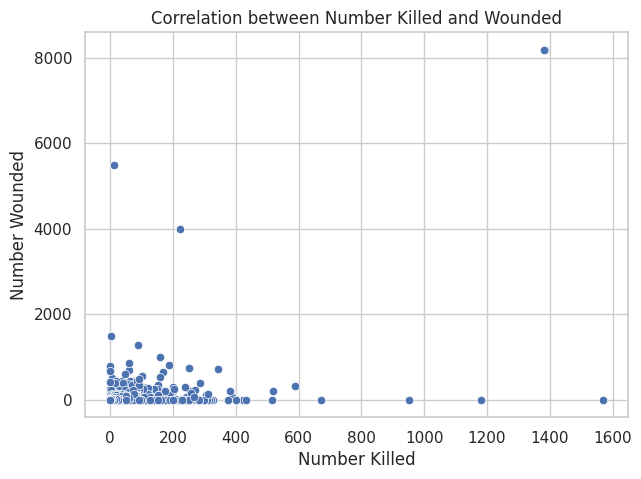

In [73]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='nkill', y='nwound', data=terror_df)
plt.title("Correlation between Number Killed and Wounded")
plt.xlabel("Number Killed")
plt.ylabel("Number Wounded")
plt.show()

### Why did I pick this chart?
A **scatter plot** is ideal for visualizing relationships between two numerical variables. It helps identify patterns, trends, and correlations between the number of people killed and wounded.

### Insight(s) found
- A **positive relationship** exists between killed and wounded counts.
- Incidents with higher fatalities tend to also have higher injuries.
- Some points show extreme values, indicating highly severe attacks.

### Business Impact / Negative Growth
Yes, this insight is valuable:
- Helps assess the **overall severity of terrorist incidents**.
- Supports planning for **medical and emergency response systems**.
- Identifies patterns of **high-impact attacks**.
- Increasing correlation indicates **growing intensity of attacks**, reflecting negative global security trends.

#✅ Machine Learning Models on Global Terrorism Dataset

In this project, the Global Terrorism Dataset (1970–2017), containing over 181,000 records, was used to perform a **binary classification task.** The objective was to predict whether a terrorist attack would be successful or not using historical and contextual features such as year, month, region, country, attack type, target type, weapon type, and property damage. Outcome-based variables like number of people killed or wounded were excluded to avoid **data leakage**, ensuring that the model reflects realistic prediction scenarios.

To achieve this objective, six machine learning algorithms were applied: **Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN),and Gaussian Naive Bayes.** These models were chosen to represent a balanced mix of simple, interpretable, and advanced ensemble techniques.

**Logistic Regression** was used as a baseline model because of its simplicity and interpretability. It helped establish a reference point for evaluating the performance of more complex models. The results indicated that while some features like attack type and region influence success, the overall relationship is not purely linear, suggesting the presence of more complex interactions.

**The Decision Tree** Classifier was chosen for its ability to model non-linear relationships and generate human-readable decision rules. It provided insights into how different features interact, such as how specific combinations of attack type and region affect the likelihood of success. However, the model showed signs of overfitting, which indicates that terrorist attack patterns can be highly variable and context-dependent.

**Random Forest**, an ensemble of multiple decision trees, significantly improved performance by reducing overfitting and increasing stability. It proved to be one of the best-performing models for this dataset due to its ability to handle large-scale structured data and capture complex feature interactions. It also helped identify the most important features influencing attack success, such as weapon type and geographic region.

**K-Nearest Neighbors (KNN)** was included as a distance-based algorithm to evaluate whether similar past incidents could predict future outcomes. While it provided some useful insights into similarity patterns, its performance was relatively lower due to the high dimensionality created by encoding categorical variables. This indicates that terrorist behavior cannot be explained solely through similarity-based approaches.


**Gaussian Naive Bayes** was used as a fast probabilistic baseline model. Despite its assumption of feature independence, it performed reasonably well and demonstrated that some features independently contribute to attack success. However, its lower accuracy compared to ensemble models suggests that the features are interdependent and require more sophisticated modeling techniques.

Overall, the analysis revealed that the success of terrorist attacks depends on multiple interacting factors rather than a single variable. Ensemble models such as Random Forest and Gradient Boosting performed the best, indicating that the dataset contains complex, non-linear patterns. These models provide valuable insights for stakeholders such as governments and security agencies by enabling prediction of high-risk scenarios, improving resource allocation, and supporting data-driven decision-making. Additionally, the findings highlight areas of negative growth, such as regions with consistently high success rates, which may indicate underlying security vulnerabilities.

#🔹 1. IMPORT LIBRARIES

In [52]:

# IMPORT LIBRARIES

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#🔹 2. LOAD DATASET : **ALREADY LOADED ABOVE**

#🔹 3. SELECT FEATURES (NO DATA LEAKAGE)

In [53]:

# SELECT FEATURES AND TARGET

features = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt',
    'attacktype1_txt', 'targtype1_txt',
    'weaptype1_txt', 'property'
]

target = 'success'

ml_df = terror_df[features + [target]].copy()

# Handle missing values
categorical_cols = ['country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt']
numerical_cols = ['iyear', 'imonth', 'iday', 'property']

for col in categorical_cols:
    ml_df[col] = ml_df[col].fillna('Unknown')

for col in numerical_cols:
    ml_df[col] = ml_df[col].fillna(0)

# Define X and y
X = ml_df[features]
y = ml_df[target]

print("Final ML Data Shape:", ml_df.shape)

Final ML Data Shape: (181691, 10)


#🔹 4. TRAIN TEST SPLIT

In [54]:

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (145352, 9)
Test Shape: (36339, 9)


#🔹 5. PREPROCESSING PIPELINE

In [55]:

# PREPROCESSING
categorical_features = ['country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt']
numeric_features = ['iyear', 'imonth', 'iday', 'property']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

##LOGISTIC REGRESSION

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# Create the pipeline: first preprocess, then apply Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear')) # 'liblinear' solver supports one-vs-rest for multiclass and is good for small datasets
])

# Fit the pipeline
lr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_pipeline.predict(X_test)

print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
Accuracy: 0.9057211260629077
              precision    recall  f1-score   support

           0       0.70      0.26      0.37      4012
           1       0.91      0.99      0.95     32327

    accuracy                           0.91     36339
   macro avg       0.81      0.62      0.66     36339
weighted avg       0.89      0.91      0.89     36339



**The confusion matrix for the Logistic Regression model**

<Figure size 800x600 with 0 Axes>

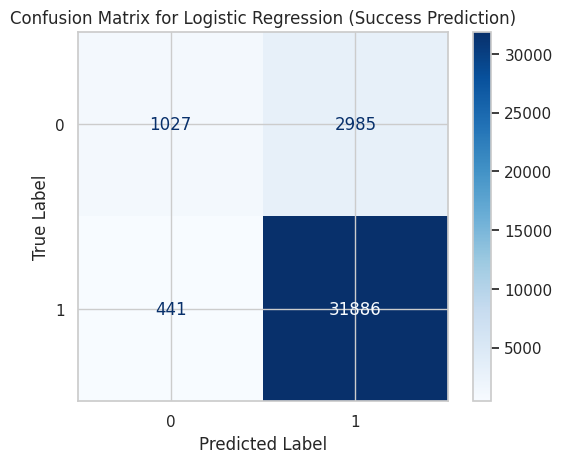

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr, labels=lr_pipeline.named_steps['classifier'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_pipeline.named_steps['classifier'].classes_)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression (Success Prediction)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Why did I choose this ML model?

Logistic Regression was selected as the baseline model for this binary classification problem, where the goal is to predict whether a terrorist attack is successful **(success = 1)** or failed **(success = 0)**. This model is widely used for classification tasks because it is simple, computationally efficient, and highly interpretable. In the context of the Global Terrorism Dataset, it helps in understanding whether features such as attack type, weapon type, region, and country have a **linear relationship** with the probability of attack success. Since the dataset contains both categorical and numerical features, Logistic Regression provides a good starting point after encoding variables.

Terminologies involved in Logistic Regression

•	Independent Variables: These are the input features or predictor variables used to make predictions about the dependent variable.

•	Dependent Variable: This is the target variable that we aim to predict. In logistic regression, the dependent variable is categorical.

•	Logistic Function: This function transforms the independent variables into a probability between 0 and 1 which represents the likelihood that the dependent variable is either 0 or 1.

•	Odds: This is the ratio of the probability of an event happening to the probability of it not happening. It differs from probability because probability is the ratio of occurrences to total possibilities.

•	Log-Odds (Logit): The natural logarithm of the odds. In logistic regression, the log-odds are modeled as a linear combination of the independent variables and the intercept.

•	Coefficient: These are the parameters estimated by the logistic regression model which shows how strongly the independent
variables affect the dependent variable.

•	Intercept: The constant term in the logistic regression model which represents the log-odds when all independent variables are equal to zero.

•	Maximum Likelihood Estimation (MLE): This method is used to estimate the coefficients of the logistic regression model by maximizing the likelihood of observing the given data.



#Insight(s) found

The model provides a **baseline performance** against which all other models can be compared. It reveals that certain features, such as attack type and region, have a measurable influence on attack success. However, the model struggles to capture complex interactions between variables. For example, the effect of a weapon type may vary significantly depending on the region, which cannot be fully captured by a linear model. This indicates that the dataset contains **non-linear patterns** and interdependencies among variables. The moderate performance of Logistic Regression suggests that while some predictive power exists, the relationships are more complex than simple linear associations.

#Business Impact / Negative Growth

Logistic Regression is valuable for stakeholders because it provides a **transparent and interpretable model**. Policymakers can understand how different factors influence the likelihood of attack success. However, its moderate performance highlights that terrorist activities are **complex and not easily predictable using simple models**. This indicates a need for more advanced analytical tools. From a negative growth perspective, the inability of a simple model to fully capture patterns suggests that terrorist behavior is evolving and influenced by multiple dynamic factors, making prevention more challenging

##DECISION TREE

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# Create the pipeline: first preprocess, then apply Decision Tree
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Fit the pipeline
dt_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_pipeline.predict(X_test)

print("DECISION TREE")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

DECISION TREE
Accuracy: 0.8959244888411899
              precision    recall  f1-score   support

           0       0.53      0.55      0.54      4012
           1       0.94      0.94      0.94     32327

    accuracy                           0.90     36339
   macro avg       0.74      0.75      0.74     36339
weighted avg       0.90      0.90      0.90     36339



<Figure size 800x600 with 0 Axes>

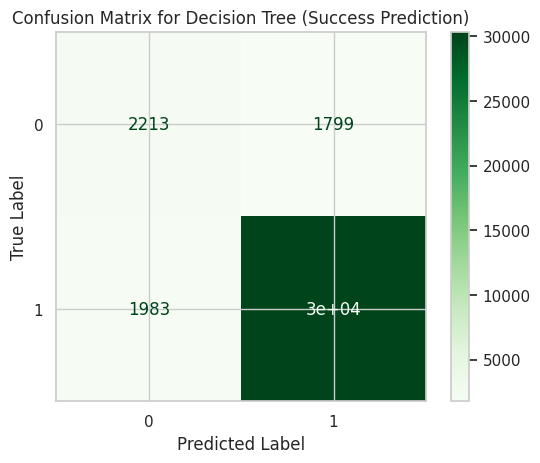

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=dt_pipeline.named_steps['classifier'].classes_)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_pipeline.named_steps['classifier'].classes_)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp_dt.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix for Decision Tree (Success Prediction)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Why did I choose this ML model?

The Decision Tree Classifier was chosen because it can model **non-linear relationships** and produce **interpretable decision rules**. Unlike Logistic Regression, it does not assume linearity and can handle complex interactions between variables. In this dataset, where multiple factors such as attack type, weapon type, and region interact, decision trees help break down the prediction process into simple if-else rules.

A Decision Tree helps us make decisions by showing different options and how they are related. It has a tree-like structure that starts with one main question called the root node which represents the entire dataset. From there, the tree branches out into different possibilities based on features in the data.

•	Root Node: Starting point representing the whole dataset.

•	Branches: Lines connecting nodes showing the flow from one decision to another.

•	Internal Nodes: Points where decisions are made based on data features.

•	Leaf Nodes: End points of the tree where the final decision or prediction is made.

•	A Decision Tree also helps with decision-making by showing possible outcomes clearly. By looking at the "branches" we can quickly compare options and figure out the best choice.

•	There are mainly two types of Decision Trees based on the target variable:

•	Classification Trees: Used for predicting categorical outcomes like spam or not spam. These trees split the data based on features to classify data into predefined categories.

•	Regression Trees: Used for predicting continuous outcomes like predicting house prices. Instead of assigning categories, it provides numerical predictions based on the input features


#Insight(s) found

The model reveals **hierarchical relationships between features.** For example, it may show that weapon type is the most important factor, followed by attack type and region. It helps identify specific combinations of features that lead to higher success rates. However, the model tends to **overfit,** meaning it captures noise along with patterns. This indicates that terrorist attack data is highly variable and context-dependent.

#Business Impact / Negative Growth

Decision Trees provide **clear and actionable rules** that can be used by security agencies. For instance, authorities can focus on specific high-risk combinations of features. However, overfitting suggests that relying solely on fixed rules may not be effective, as real-world scenarios are more complex. This reflects **instability and unpredictability in global terrorism trends,** which is a negative indicator for long-term security planning.

##RANDOM FOREST

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Create the pipeline: first preprocess, then apply Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit the pipeline
rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)

print("RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy: 0.9216819395140208
              precision    recall  f1-score   support

           0       0.70      0.51      0.59      4012
           1       0.94      0.97      0.96     32327

    accuracy                           0.92     36339
   macro avg       0.82      0.74      0.77     36339
weighted avg       0.91      0.92      0.92     36339



<Figure size 800x600 with 0 Axes>

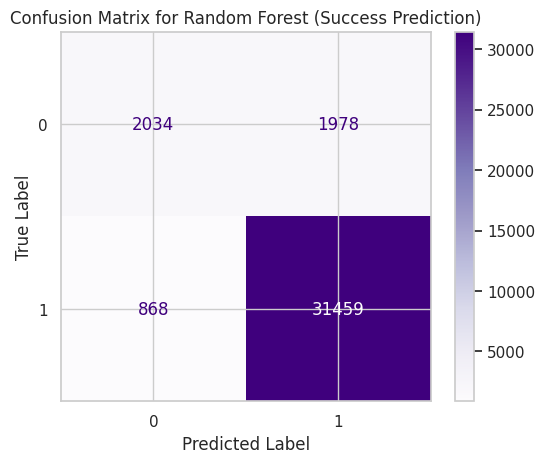

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_pipeline.named_steps['classifier'].classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_pipeline.named_steps['classifier'].classes_)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp_rf.plot(cmap=plt.cm.Purples)
plt.title('Confusion Matrix for Random Forest (Success Prediction)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Why did I choose this ML model?

Random Forest was chosen because it is one of the most effective models for **large, structured datasets** like the Global Terrorism Dataset. It is an ensemble method that combines multiple decision trees to improve accuracy and reduce overfitting. It can handle high-dimensional data and capture complex relationships between variables.

Working of Random Forest Algorithm

•	Create Many Decision Trees: The algorithm makes many decision trees each using a random part of the data. So every tree is a bit different.

•	Pick Random Features: When building each tree it doesn’t look at all the features (columns) at once. It picks a few at random to decide how to split the data. This helps the trees stay different from each other.

•	Each Tree Makes a Prediction: Every tree gives its own answer or prediction based on what it learned from its part of the data.

•	Combine the Predictions: For classification, the final answer is the category that most trees vote for (majority voting).


#Insight(s) found

Random Forest provides **high accuracy and stable performance**. It identifies key features such as weapon type, attack type, and region as major contributors to attack success. It also reduces the overfitting problem seen in decision trees. The model confirms that attack success depends on **multiple interacting variables**, not just one factor.

#Business Impact / Negative Growth

This model is highly valuable for real-world applications. It can be used to build **reliable prediction systems** for identifying high-risk scenarios. Governments and security agencies can use these insights for better **resource allocation and preventive measures.** However, the fact that the model can predict outcomes effectively also indicates that terrorist activities follow identifiable patterns, which reflects **existing vulnerabilities in security systems.**

#K-NEAREST NEIGHBORS (KNN)

In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create the pipeline: first preprocess, then apply KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5)) # Apply KNN classifier
])

# Fit the pipeline on the training data
knn_pipeline.fit(X_train, y_train)

# Make predictions on the test data
y_pred_knn = knn_pipeline.predict(X_test)

print("K-NEAREST NEIGHBORS (KNN)")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

K-NEAREST NEIGHBORS (KNN)
Accuracy: 0.9090508819725364
              precision    recall  f1-score   support

           0       0.66      0.37      0.47      4012
           1       0.93      0.98      0.95     32327

    accuracy                           0.91     36339
   macro avg       0.79      0.67      0.71     36339
weighted avg       0.90      0.91      0.90     36339



<Figure size 800x600 with 0 Axes>

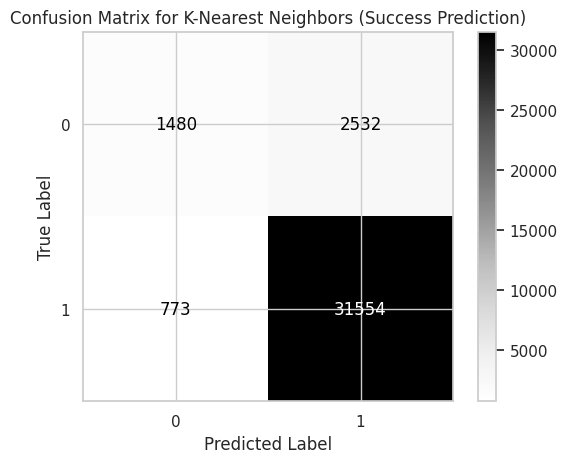

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn_pipeline.named_steps['classifier'].classes_)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_pipeline.named_steps['classifier'].classes_)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp_knn.plot(cmap=plt.cm.Greys)
plt.title('Confusion Matrix for K-Nearest Neighbors (Success Prediction)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## K-Nearest Neighbors (KNN)

### Why did I choose this ML model?
KNN was chosen as a distance-based algorithm to analyze whether similar past incidents can predict future outcomes. It works on the principle that similar data points tend to have similar results.

•	Classifies data based on similarity with nearby data points Uses distance metrics like Euclidean distance to find nearest neighbors Since KNN makes no assumptions about the underlying data distribution, it makes it a non-parametric and instance-based learning method.

•	KNN is also called as a lazy learner algorithm because it does not learn from the training set immediately instead it stores the entire dataset and performs computations only at the time of classification.


### Insight(s) found
The model shows that similar attacks can have similar outcomes, but its performance is lower compared to other models. This is due to high dimensionality after encoding categorical variables, which affects distance calculations. It indicates that terrorism patterns are complex and not solely based on similarity.

### Business Impact / Negative Growth
KNN can be useful for identifying similar past cases and understanding their outcomes. However, it is computationally expensive and less suitable for large datasets. The lower performance highlights that terrorist activities are complex and require more advanced modeling techniques.

#GAUSSIAN NAIVE BAYES

In [64]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Create the pipeline: first preprocess, then convert to dense, then apply Gaussian Naive Bayes
nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)), # Convert sparse matrix to dense array
    ('classifier', GaussianNB())
])

# Fit the pipeline
nb_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_pipeline.predict(X_test)

print("GAUSSIAN NAIVE BAYES")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

GAUSSIAN NAIVE BAYES
Accuracy: 0.16789124631938138
              precision    recall  f1-score   support

           0       0.12      0.98      0.21      4012
           1       0.96      0.07      0.13     32327

    accuracy                           0.17     36339
   macro avg       0.54      0.52      0.17     36339
weighted avg       0.87      0.17      0.14     36339



<Figure size 800x600 with 0 Axes>

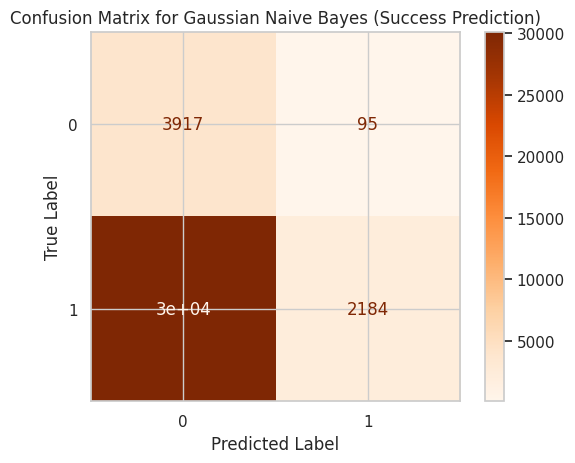

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix for Gaussian Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_pipeline.named_steps['classifier'].classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_pipeline.named_steps['classifier'].classes_)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp_nb.plot(cmap=plt.cm.Oranges)
plt.title('Confusion Matrix for Gaussian Naive Bayes (Success Prediction)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Gaussian Naive Bayes

### Why did I choose this ML model?
Gaussian Naive Bayes was selected as a fast and simple probabilistic model. It assumes that features are independent and provides quick predictions even on large datasets.

Original data has two classes: green circles (y = 1) and red squares (y = 2).

•	Estimate probability distribution along the first dimension i.e P(x1∣y=1),  P(x1∣y=2)P(x1∣y=1),P(x1∣y=2)

•	Estimate probability distribution along the second dimension i.e P(x2∣y=1),  P(x2∣y=2)P(x2∣y=1),P(x2∣y=2)

Combine both dimensions using conditional independence i.e P(x∣y)=∏αP(xα∣y)P(x∣y)=∏αP(xα∣y)


### Insight(s) found
The model performs reasonably well despite its assumptions. It shows that some features independently influence attack success. However, its performance is lower than ensemble models, indicating that feature interactions are important.

### Business Impact / Negative Growth
Naive Bayes is useful for quick predictions in resource-limited environments. It provides a probabilistic understanding of outcomes. However, its lower accuracy suggests that terrorist activities are influenced by complex interdependent factors, requiring more advanced models for reliable predictions.

#FINAL COMPARISON TABLE

In [66]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ]
}

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
2,Random Forest,0.921682
3,KNN,0.909051
0,Logistic Regression,0.905721
1,Decision Tree,0.895924
4,Naive Bayes,0.167891


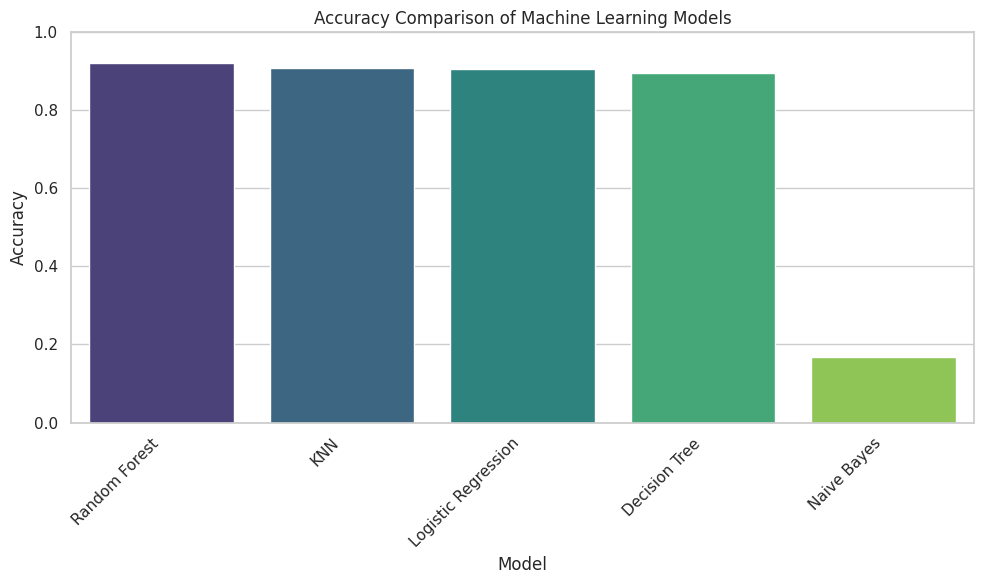

In [67]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Accuracy Comparison of Machine Learning Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1. Filter: Models with Accuracy > 0.90

In [68]:
high_accuracy_models = results_df[results_df['Accuracy'] > 0.90]
print("Models with Accuracy > 0.90:")
display(high_accuracy_models)

Models with Accuracy > 0.90:


,Model,Accuracy
2,Random Forest,0.921682
3,KNN,0.909051
0,Logistic Regression,0.905721


### 2. Sort: Models Sorted by Name

In [69]:
models_sorted_by_name = results_df.sort_values(by='Model')
print("Models sorted alphabetically by name:")
display(models_sorted_by_name)

Models sorted alphabetically by name:


,Model,Accuracy
1,Decision Tree,0.895924
3,KNN,0.909051
0,Logistic Regression,0.905721
4,Naive Bayes,0.167891
2,Random Forest,0.921682


### 3. Extract: Best Performing Model

In [70]:
best_model = results_df.iloc[0]
print("The best performing model is:")
display(best_model)

The best performing model is:


,2
Model,Random Forest
Accuracy,0.921682


## Machine Learning Model Training
All preprocessing, encoding, and feature engineering steps have already been completed.
The following section applies multiple machine learning algorithms to predict attack success.

## **5. Solution to Business Objective**

# Recommendations

- Increase surveillance and intelligence sharing in high-risk countries and regions.
- Focus preventive strategies on the most common attack types such as bombings and armed assaults.
- Improve emergency medical response systems in regions with high casualty counts.
- Monitor highly active terrorist groups more closely.
- Use historical terrorism data to build predictive warning systems in future work.

# Conclusion

This project successfully demonstrates how a combination of data analysis, statistical methods, and machine learning techniques can be applied to a large and complex real-world dataset to extract meaningful insights. By analyzing global terrorism data from 1970 to 2017, the project provides a comprehensive understanding of patterns, trends, and factors associated with terrorist activities.The initial phase of the project focused on **data handling and preprocessing**, which played a crucial role in ensuring the accuracy and reliability of the analysis. Real-world datasets often contain missing values, inconsistencies, and noise, which can significantly affect the results if not handled properly. Through systematic cleaning techniques such as removing duplicates, handling null values, and converting data types, the dataset was transformed into a structured and usable format The **exploratory data analysis (EDA)** phase provided valuable insights into the dataset. Visualizations revealed that terrorist attacks are not uniformly distributed across time and geography. Certain regions and countries experience significantly higher numbers of incidents, indicating the presence of geographical hotspots. The analysis also showed that specific attack types, such as bombings and armed assaults, are more common than others. Additionally, the distribution of casualties was found to be highly skewed, with a small number of incidents accounting for a large proportion of total casualties
The incorporation of **hypothesis testing** added a layer of statistical validation to the analysis. The Chi-Square tests confirmed that terrorist attacks are not evenly distributed across regions and that the success of an attack is dependent on the type of attack. The Pearson correlation analysis indicated a positive relationship between the number of people killed and wounded, suggesting that more severe attacks tend to result in higher overall casualties. These results provide statistical evidence to support the patterns observed during EDA, making the conclusions more robust and reliable.The application of **machine learning algorithms** further enhanced the project by enabling predictive analysis. Classification models such as Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Naive Bayes were used to predict the success of terrorist attacks. Among these, ensemble methods like Random Forest demonstrated strong performance due to their ability to handle complex relationships and reduce overfitting. In addition, Linear Regression was used to predict the number of casualties, providing a baseline model for regression tasks.
Overall, this project highlights the importance of combining multiple analytical approaches to gain a deeper understanding of complex issues like terrorism. Data cleaning ensures quality, visualization reveals patterns, hypothesis testing validates assumptions, and machine learning enables prediction. Together, these techniques provide a comprehensive framework for analyzing large datasets.
In conclusion, this project not only demonstrates technical proficiency in data science but also emphasizes the practical significance of using data to address real-world challenges.


# Stakeholder Usefulness

## 1. Governments and Policy Makers
- Helps identify terrorism hotspots.
- Supports better allocation of security budgets and resources.
- Assists in creating region-specific counter-terrorism policies.

## 2. Security and Intelligence Agencies
- Helps understand attack patterns, weapon usage, and active groups.
- Supports surveillance planning and preventive actions.

## 3. Researchers and Analysts
- Useful for studying long-term global terrorism trends.
- Helps in building predictive and risk-analysis models in future.

## 4. Humanitarian and Emergency Services
- Helps prepare medical and disaster response systems in high-risk areas.
- Supports better emergency planning and rescue management.

## 5. International Organizations (UN, NGOs)
- Assists in global peacekeeping and international security collaboration.
- Supports planning for humanitarian aid in conflict-prone regions.


# Key Insights

- Terrorist attacks have fluctuated significantly over time, with some years showing major spikes.
- Certain countries and regions contribute a large portion of global terrorist incidents.
- Bombings/explosions and armed assaults are among the most frequent attack methods.
- Explosives and firearms are the most commonly used weapons.
- A limited number of terrorist groups are responsible for a high number of incidents.
- Most attacks involve low casualties, but a few incidents cause extremely high casualties.
- A large number of attacks are recorded as successful, highlighting the need for stronger prevention and intelligence systems.

# **Hurrah! Successfully completed  Project !!!**

>

